### Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from boruta import BorutaPy
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from matplotlib.patches import Patch
from scipy.stats import pointbiserialr
from imblearn.combine import SMOTETomek
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, accuracy_score, f1_score, roc_curve,precision_score, confusion_matrix, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, 
                             roc_auc_score, recall_score, cohen_kappa_score)
from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest, RFE, RFECV, SequentialFeatureSelector, VarianceThreshold, f_classif
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier

import warnings
warnings.filterwarnings('ignore')

## Load data

In [ ]:
# df_ch = pd.read_spss(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")
df_ch = pd.read_spss('/workspaces/malnutrition/Dataset/ch.sav')
df_ch.head(2)

,HH1,HH2,LN,UF1,UF2,UF3,UFINT,UF4,UF5,UF6,...,wscoreu,windex5u,windex10u,wscorer,windex5r,windex10r,ListCat,PSU,dstratum,stratum
0,1.0,3.0,5.0,1.0,3.0,5.0,103.0,4.0,103.0,100.0,...,NaN,NaN,NaN,-0.831559,Second,3rd decile,With child U5 during listing,1.0,"U5 HH, Province 1 Rural",Province 1 Rural
1,1.0,5.0,5.0,1.0,5.0,5.0,104.0,2.0,104.0,100.0,...,NaN,NaN,NaN,-1.220021,Poorest,2nd decile,With child U5 during listing,1.0,"U5 HH, Province 1 Rural",Province 1 Rural


In [3]:
# Rename columns
feature_coded = df_ch[['EC3A', 'EC3B', 'EC9', 'UCD2A', 'UCD2B', 'UCD2C', 'UCF4', 'BD2', 'BD3', 'IM2', 'cdisability', 'BD9', 'AN4', 'CA1', 'CA14', 'HH6', 'HL4', 
                       'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2', 'CA31', 'CA16']]

df1 = feature_coded.rename(columns={
    # Child supervision / discipline
    'EC3A': 'left alone',
    'EC3B': 'left with child',
    'EC9': 'can pick up',
    'UCD2A': 'away privileges',
    'UCD2B': 'behaviour explained',
    'UCD2C': 'shook',

    #Child mobility & disability
    'UCF4': 'walking assistance',
    'cdisability': 'child disability',

    # Feeding & nutrition practices
    'BD2': 'ever breastfed',
    'BD3': 'currently breastfed',
    'BD9': 'meal freqency',

    # Health & illness
    'IM2': 'vaccination card',
    'CA1': 'recent diarrhoea',
    'CA14': 'recent fever',
    'CA16': 'recent cough',

    # Demographics
    'AN4': 'child age',
    'HL4': 'child sex',

    # Household & socioeconomic
    'HH6': 'residence type',
    'HH7c': 'province',
    'melevel1': 'mother education',
    'cinsurance': 'health insurance',
    'CA31': 'stool disposal',
    'windex5': 'wealth index',

    # Target
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting', 
})

# Rename Provinces
province_map = {
    'Province 1': 'koshi',
    'Province 2': 'madhesh',
    'Province 5': 'lumbini',
    'Bagmati Province': 'bagmati',
    'Gandaki Province': 'gandaki',
    'Karnali Province': 'karnali',
    'Sudoorpaschim Province': 'sudoorpaschim'
}

df1['province'] = df1['province'].replace(province_map)


df = df1.copy()

# 1. Clean and create target variables FIRST
# Remove invalid/missing measurements
invalid_values = ['Z-score out of range', 'Not measured', 'Measurement out of range', 
                  ' Measurement out of range', 'DK', 'NO RESPONSE', 'Missing/DK']

df = df[~df['underweight'].isin(invalid_values)]
df = df[~df['stunting'].isin(invalid_values)]
df = df[~df['wasting'].isin(invalid_values)]

# Convert to numeric
df['underweight'] = pd.to_numeric(df['underweight'], errors='coerce')
df['stunting'] = pd.to_numeric(df['stunting'], errors='coerce')
df['wasting'] = pd.to_numeric(df['wasting'], errors='coerce')

# Drop any remaining NaN in target variables
df = df.dropna(subset=['underweight', 'stunting', 'wasting'])

# 2. Create binary indicators
df['underweight_binary'] = (df['underweight'] < -2).astype(int)
df['stunting_binary'] = (df['stunting'] < -2).astype(int)
df['wasting_binary'] = (df['wasting'] < -2).astype(int)

# 3. Create composite malnutrition target (if any indicator is positive)
df['malnutrition'] = ((df['underweight_binary'] == 1) | 
                      (df['stunting_binary'] == 1) | 
                      (df['wasting_binary'] == 1)).astype(int)

# 4. Drop the z-scores and individual binary indicators (CRITICAL - prevent data leakage)
# Keep only the composite target
df = df.drop(['underweight', 'stunting', 'wasting', 
              'underweight_binary', 'stunting_binary', 'wasting_binary'], axis=1)

# 5. Handle missing values in features
# Convert categorical to object
for col in df.columns:
    if col != 'malnutrition' and df[col].dtype.name == 'category':
        df[col] = df[col].astype('object')

# Replace specific missing indicators
replace_dict = {
    'DK': 'Not asked',
    'NO RESPONSE': 'Not asked',
    'Missing/DK': 'Not asked',
    'NONE': '0'  # Keep as string for consistency
}
df = df.replace(replace_dict)

# Fill remaining NaN
df = df.fillna('Not asked')

print(f"Final dataset shape: {df.shape}")
print(f"\nTarget distribution:\n{df['malnutrition'].value_counts()}")
print(f"\nMissing values:{df.isnull().sum().sum()}")

Final dataset shape: (6416, 24)

Target distribution:
malnutrition
0    3671
1    2745
Name: count, dtype: int64

Missing values:0


We selected explanatory variables spanning child demographics, health and morbidity, feeding and caregiving practices, maternal characteristics, and household socioeconomic and environmental conditions. These variables were chosen based on prior empirical research identifying key determinants of child malnutrition, as well as their availability in the Multiple Indicator Cluster Surveys (MICS) dataset. The selected features reflect established pathways through which biological, behavioral, and contextual factors influence nutritional outcomes in early childhood.

In [4]:
# Value counts for each column
for col in df.columns:
    print(f"="*20)
    print(df[col].value_counts())

left alone
0            5020
7.0           526
2.0           253
1.0           155
3.0           136
4.0           116
5.0           111
6.0            57
Not asked      42
Name: count, dtype: int64
left with child
0            5302
7.0           269
2.0           256
1.0           203
3.0           133
5.0           104
4.0            76
Not asked      39
6.0            34
Name: count, dtype: int64
can pick up
Not asked    3587
YES          2665
NO            164
Name: count, dtype: int64
away privileges
NO           3292
YES          2071
Not asked    1053
Name: count, dtype: int64
behaviour explained
YES          4229
NO           1141
Not asked    1046
Name: count, dtype: int64
shook
NO           3453
YES          1916
Not asked    1047
Name: count, dtype: int64
walking assistance
NO           3919
Not asked    2315
YES           182
Name: count, dtype: int64
ever breastfed
YES          3316
Not asked    2844
NO            256
Name: count, dtype: int64
currently breastfed
Not asked

In [5]:
df['province'].value_counts()

province
bagmati          1191
madhesh          1015
lumbini           987
koshi             947
sudoorpaschim     822
karnali           743
gandaki           711
Name: count, dtype: int64

## Encode 

In [6]:
def encode_all_features_keep_not_asked(df):
    """
    Encoding pipeline:
    - 'Not asked' → -1 for behavioral/ternary variables (age-dependent questions)
    - 'Not asked' → imputed for variables with very few "Not asked" (<1%)
    - Ordinal variables encoded with natural ordering
    """
    df = df.copy()
    
    # 1. ORDINAL ENCODING
    wealth_order = {'Poorest': 1, 'Second': 2, 'Middle': 3, 'Fourth': 4, 'Richest': 5}
    df['wealth index'] = df['wealth index'].map(wealth_order)
    
    # Mother education: only 3 "Not asked" (0.05%) - safe to impute
    education_order = {
        'None': 0, 
        'Basic (Gr 1-8)': 1, 
        'Secondary (Gr 9-12)': 2, 
        'Higher': 3, 
        'Not asked': np.nan
    }
    df['mother education'] = df['mother education'].map(education_order)
    edu_mode = df['mother education'].mode().iloc[0]
    df['mother education'] = df['mother education'].fillna(edu_mode)
    
    df['child age'] = pd.to_numeric(df['child age'], errors='coerce')
    
    # Meal frequency: high "Not asked" (64%) - keep as -1
    df['meal freqency'] = df['meal freqency'].replace({'7+': 7, 'Not asked': -1})
    df['meal freqency'] = pd.to_numeric(df['meal freqency'], errors='coerce')
    
    # 2. TERNARY ENCODING (YES/NO/NOT ASKED)
    # Use -1 for age-dependent questions (high "Not asked")
    # Use np.nan for questions with very low "Not asked" that we'll impute
    ternary_columns = {
        # Age-dependent (high "Not asked") → use -1
        'can pick up': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'away privileges': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'behaviour explained': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'shook': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'walking assistance': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'ever breastfed': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'currently breastfed': {'YES': 1, 'NO': 0, 'Not asked': -1},
        'child disability': {'Has functional difficulty': 1, 'Has no functional difficulty': 0, 'Not asked': -1},
        
        # Very low "Not asked" (<1%) → use np.nan and impute
        'recent diarrhoea': {'YES': 1, 'NO': 0, 'Not asked': np.nan},
        'recent fever': {'YES': 1, 'NO': 0, 'Not asked': np.nan},
        'recent cough': {'YES': 1, 'NO': 0, 'Not asked': np.nan},
        'health insurance': {'With insurance': 1, 'Without insurance': 0, 'Not asked': np.nan}
    }
    
    for col, mapping in ternary_columns.items():
        df[col] = df[col].map(mapping)
    
    # Impute the few NaN values (for variables with <1% "Not asked")
    for col in ['recent diarrhoea', 'recent fever', 'recent cough', 'health insurance']:
        if df[col].isnull().any():
            mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 0
            df[col] = df[col].fillna(mode_val)
    
    # 3. BINARY ENCODING (no "Not asked")
    binary_only = {
        'residence type': {'URBAN': 1, 'RURAL': 0},
        'child sex': {'MALE': 1, 'FEMALE': 0}
    }
    
    for col, mapping in binary_only.items():
        df[col] = df[col].map(mapping)
    
    # 4. NUMERIC/COUNT VARIABLES (use -1 for "Not asked")
    df['left alone'] = pd.to_numeric(df['left alone'].replace('Not asked', -1), errors='coerce')
    df['left with child'] = pd.to_numeric(df['left with child'].replace('Not asked', -1), errors='coerce')
    
    # 5. BINARY CONVERSION for stool disposal and vaccination
    safe_disposal = [
        'PUT / RINSED INTO: TOILET OR LATRINE',
        'CHILD USED TOILET / LATRINE',
        'BURIED'
    ]
    unsafe_disposal = [
        'LEFT IN THE OPEN',
        'THROWN INTO GARBAGE (SOLID WASTE)',
        'PUT / RINSED INTO: DRAIN OR DITCH',
        'OTHER'
    ]
    
    df['safe stool disposal'] = df['stool disposal'].apply(
        lambda x: 1 if x in safe_disposal else (0 if x in unsafe_disposal else -1)
    )
    df = df.drop('stool disposal', axis=1)
    
    df['vaccination record'] = df['vaccination card'].apply(
        lambda x: 1 if x in ['YES, HAS ONLY CARD(S)', 
                              'YES, HAS CARD(S) AND OTHER DOCUMENT',
                              'YES, HAS ONLY OTHER DOCUMENT'] 
                  else (0 if x == 'NO, HAS NO CARDS AND NO OTHER DOCUMENT' else -1)
    )
    df = df.drop('vaccination card', axis=1)
    
    # 6. ONE-HOT ENCODE PROVINCE
    df = pd.get_dummies(df, columns=['province'], dtype=int)
    df = df.drop(columns=['province_bagmati'])     # Drop 'province_Bagmati'
    df = df.rename(columns=lambda c: c.replace('province_', ''))
    
    print("="*60)
    print("ENCODING COMPLETE")
    print("="*60)
    print(f"Shape: {df.shape}")
    print(f"\nEncoding scheme:")
    print("  • Age-dependent variables: 1/0/-1 (YES/NO/Not asked)")
    print("  • Low-missingness variables: 1/0 (imputed)")
    print("  • Ordinal variables: Natural order")
    print("  • Province: One-hot encoded")
    
    return df

# Apply encoding
df_encoded = encode_all_features_keep_not_asked(df)

# Verify - NO dropna() needed!
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)
print(f"Missing values: {df_encoded.isnull().sum().sum()}")
print(f"Shape: {df_encoded.shape}")

# If there are still any NaN (shouldn't be), show which columns
if df_encoded.isnull().sum().sum() > 0:
    print("\n Remaining missing values:")
    print(df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0])
else:
    print("\n No missing values")

# Check distribution of -1 values (Not asked)
print("\n" + "="*60)
print("'NOT ASKED' (-1) DISTRIBUTION")
print("="*60)
not_asked_summary = []
for col in df_encoded.columns:
    if col.startswith('province') or col == 'malnutrition':
        continue
    if df_encoded[col].dtype in ['float64', 'int64']:
        n_not_asked = (df_encoded[col] == -1).sum()
        if n_not_asked > 0:
            pct = n_not_asked / len(df_encoded) * 100
            not_asked_summary.append({
                'Feature': col,
                'Count': n_not_asked,
                'Percentage': pct
            })

if not_asked_summary:
    import pandas as pd
    summary_df = pd.DataFrame(not_asked_summary).sort_values('Percentage', ascending=False)
    print(summary_df.to_string(index=False))
else:
    print("No features with -1 values")

ENCODING COMPLETE
Shape: (6416, 29)

Encoding scheme:
  • Age-dependent variables: 1/0/-1 (YES/NO/Not asked)
  • Low-missingness variables: 1/0 (imputed)
  • Ordinal variables: Natural order
  • Province: One-hot encoded

VERIFICATION
Missing values: 0
Shape: (6416, 29)

 No missing values

'NOT ASKED' (-1) DISTRIBUTION
            Feature  Count  Percentage
      meal freqency   4117   64.167706
        can pick up   3587   55.907107
currently breastfed   3100   48.316708
 vaccination record   2847   44.373441
safe stool disposal   2846   44.357855
     ever breastfed   2844   44.326683
 walking assistance   2315   36.081671
   child disability   2314   36.066085
    away privileges   1053   16.412095
              shook   1047   16.318579
behaviour explained   1046   16.302993
         left alone     42    0.654613
    left with child     39    0.607855


### UNDERSTAND WHY DATA IS MISSING (Most Important!)
Missing data is NOT random - it's systematic based on child age:

- Breastfeeding questions → Only asked for children 0-2 years → introduced a category "Not asked"
- "Can pick up" questions → Only for younger children → introduced a category "Not asked"
- Meal frequency → Age-dependent → introduced a category "Not asked"
- Vaccination/stool disposal → Only for certain age groups → introduced a category "Not asked"


For age-dependent variables, 'Not asked' responses were encoded as -1, distinguishing them from 'No' (0) and 'Yes' (1). This encoding preserves the informative pattern that certain questions were only applicable to specific age groups, allowing models to learn age-specific risk factors.

In [7]:
# ============================================
# PREPARE DATA
# ============================================

# Final dataset ready for modeling
df_final = df_encoded.copy()
X = df_final.drop('malnutrition', axis=1)
y = df_final['malnutrition']

print("\n" + "="*60)
print("READY FOR MODELING")
print("="*60)
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("="*60)
print("DATASET INFO")
print("="*60)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Total features: {X.shape[1]}")
print(f"Class distribution (original): {y.value_counts(normalize=True).round(3).to_dict()}")
print(f"Class distribution (after SMOTE): {pd.Series(y_train).value_counts(normalize=True).round(3).to_dict()}")


READY FOR MODELING
Features (X): (6416, 28)
Target (y): (6416,)
Class distribution: {0: 3671, 1: 2745}
DATASET INFO
Training set: (5872, 28)
Test set: (1284, 28)
Total features: 28
Class distribution (original): {0: 0.572, 1: 0.428}
Class distribution (after SMOTE): {0: 0.5, 1: 0.5}



METHOD 1: FILTER METHODS

[1/5] Mutual Information...


[2/5] Chi-Square Test...
[3/5] Variance Analysis...
[4/5] Correlation with Target...
[5/5] ANOVA F-Test...

 Filter methods complete

METHOD 2: WRAPPER METHODS

[1/3] RFE with Logistic Regression...
[2/3] RFE with Gradient Boosting...
[3/3] Sequential Forward Selection...

 Wrapper methods complete

METHOD 3: EMBEDDED METHODS

[1/4] Random Forest Importance...
[2/4] Gradient Boosting Importance...
[3/4] Logistic Regression (L1) Coefficients...
[4/4] XGBoost Importance...

 Embedded methods complete

METHOD 4: BORUTA ALGORITHM

Running Boruta feature selection (this may take a few minutes)...

✓ Boruta complete!
  • Confirmed: 16
  • Tentative: 1
  • Rejected: 11

AGGREGATING ALL METHODS

TOP 20 FEATURES (BY COMBINED SCORE)
            Feature  Average_Rank Boruta_Status  Consensus  MI_Score  GB_Importance  RF_Importance
   mother education      1.818182     Confirmed         11  0.042519       0.243667       0.093162
       wealth index      2.545455     Confirmed         11  0.012051 

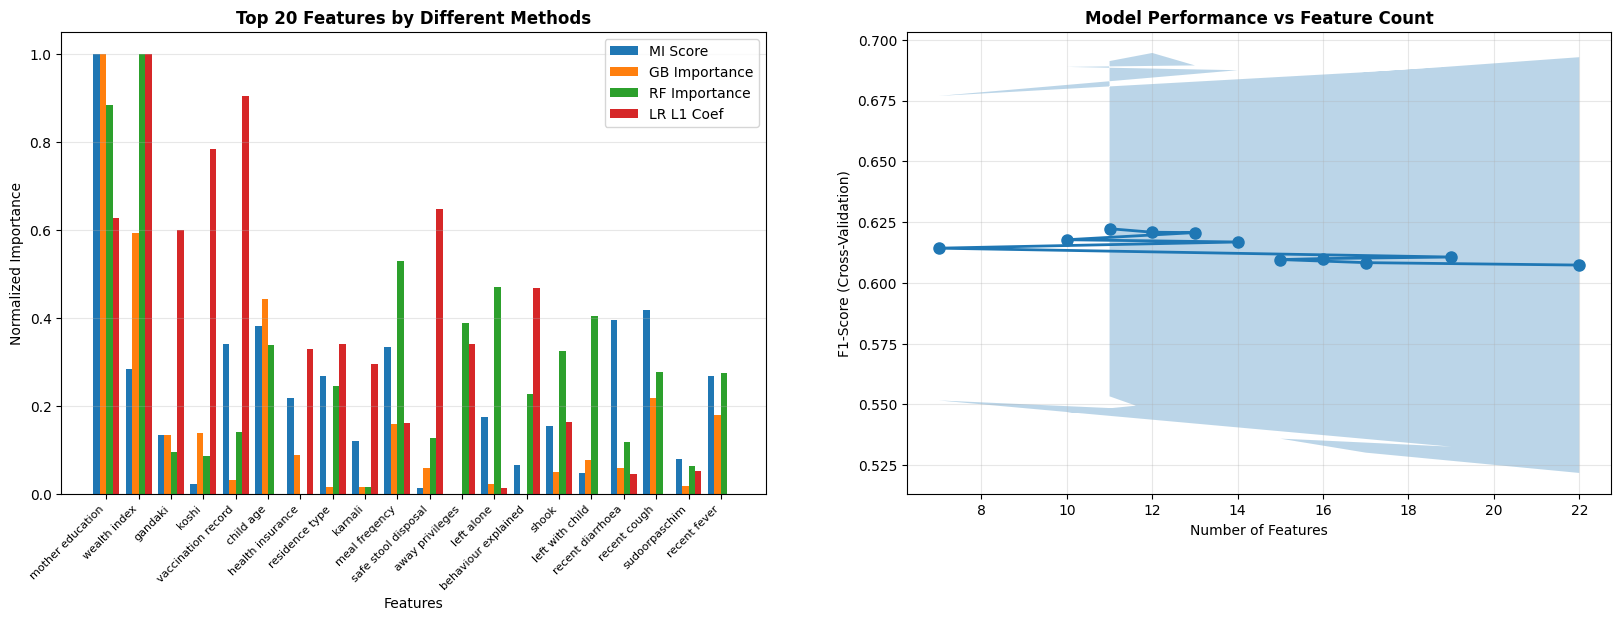

In [8]:
# ============================================
# METHOD 1: FILTER METHODS (Fast, Model-agnostic)
# ============================================

print("\n" + "="*60)
print("METHOD 1: FILTER METHODS")
print("="*60)

# Initialize results dataframe
feature_scores = pd.DataFrame({'Feature': X.columns})

# 1A. MUTUAL INFORMATION (Best for capturing non-linear relationships)
print("\n[1/5] Mutual Information...")
mi_scores = mutual_info_classif(X_train, y_train, random_state=42, n_neighbors=3)
feature_scores['MI_Score'] = mi_scores
feature_scores['MI_Rank'] = feature_scores['MI_Score'].rank(ascending=False)

# 1B. CHI-SQUARE (Good for categorical/binary features)
print("[2/5] Chi-Square Test...")
# Chi2 requires non-negative features
X_train_nonneg = X_train - X_train.min() + 1e-10
chi2_scores, chi2_pvalues = chi2(X_train_nonneg, y_train)
feature_scores['Chi2_Score'] = chi2_scores
feature_scores['Chi2_PValue'] = chi2_pvalues
feature_scores['Chi2_Rank'] = feature_scores['Chi2_Score'].rank(ascending=False)

# 1C. VARIANCE THRESHOLD (Remove low-variance features)
print("[3/5] Variance Analysis...")
var_threshold = VarianceThreshold(threshold=0.01)
var_threshold.fit(X_train)
feature_scores['Variance'] = X_train.var().values
feature_scores['Low_Variance'] = ~var_threshold.get_support()

# 1D. POINTBISERIAL CORRELATION WITH TARGET (For quick insights)
print("[4/5] Correlation with Target...")
correlations = []
for col in X_train.columns:
    corr, _ = pointbiserialr(X_train[col], y_train)

    # corr = np.corrcoef(X_train[col], y_train)[0, 1]
    correlations.append(abs(corr))
feature_scores['Abs_Correlation'] = correlations
feature_scores['Corr_Rank'] = feature_scores['Abs_Correlation'].rank(ascending=False)

# 1E. ANOVA F-statistic (Classic statistical test)
print("[5/5] ANOVA F-Test...")
f_scores, f_pvalues = f_classif(X_train, y_train)
feature_scores['F_Score'] = f_scores
feature_scores['F_PValue'] = f_pvalues
feature_scores['F_Rank'] = feature_scores['F_Score'].rank(ascending=False)

print("\n Filter methods complete")

# ============================================
# METHOD 2: WRAPPER METHODS (Slower, Model-specific)
# ============================================

print("\n" + "="*60)
print("METHOD 2: WRAPPER METHODS")
print("="*60)

# Scale features for wrapper methods
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2A. RECURSIVE FEATURE ELIMINATION (RFE) with Logistic Regression
print("\n[1/3] RFE with Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
rfe_lr = RFE(estimator=lr, n_features_to_select=20, step=1)
rfe_lr.fit(X_train_scaled, y_train)
feature_scores['RFE_LR_Selected'] = rfe_lr.support_
feature_scores['RFE_LR_Rank'] = rfe_lr.ranking_

# 2B. RECURSIVE FEATURE ELIMINATION with Gradient Boosting
print("[2/3] RFE with Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
rfe_gb = RFE(estimator=gb, n_features_to_select=20, step=1)
rfe_gb.fit(X_train_scaled, y_train)
feature_scores['RFE_GB_Selected'] = rfe_gb.support_
feature_scores['RFE_GB_Rank'] = rfe_gb.ranking_

# 2C. SEQUENTIAL FEATURE SELECTION (Forward selection)
print("[3/3] Sequential Forward Selection...")
sfs = SequentialFeatureSelector(
    lr, 
    n_features_to_select=20, 
    direction='forward',
    scoring='f1',
    cv=3,
    n_jobs=-1
)
sfs.fit(X_train_scaled, y_train)
feature_scores['SFS_Selected'] = sfs.support_

print("\n Wrapper methods complete")

# ============================================
# METHOD 3: EMBEDDED METHODS (Model-based importance)
# ============================================

print("\n" + "="*60)
print("METHOD 3: EMBEDDED METHODS")
print("="*60)

# 3A. RANDOM FOREST FEATURE IMPORTANCE
print("\n[1/4] Random Forest Importance...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
feature_scores['RF_Importance'] = rf.feature_importances_
feature_scores['RF_Rank'] = feature_scores['RF_Importance'].rank(ascending=False)

# 3B. GRADIENT BOOSTING FEATURE IMPORTANCE
print("[2/4] Gradient Boosting Importance...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
feature_scores['GB_Importance'] = gb.feature_importances_
feature_scores['GB_Rank'] = feature_scores['GB_Importance'].rank(ascending=False)

# 3C. LOGISTIC REGRESSION COEFFICIENTS (L1-regularized for sparsity)
print("[3/4] Logistic Regression (L1) Coefficients...")
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
lr_l1.fit(X_train_scaled, y_train)
feature_scores['LR_L1_Coef'] = np.abs(lr_l1.coef_[0])
feature_scores['LR_L1_Rank'] = feature_scores['LR_L1_Coef'].rank(ascending=False)

# 3D. XGBOOST IMPORTANCE (if available)
print("[4/4] XGBoost Importance...")
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
    xgb.fit(X_train, y_train)
    feature_scores['XGB_Importance'] = xgb.feature_importances_
    feature_scores['XGB_Rank'] = feature_scores['XGB_Importance'].rank(ascending=False)
except ImportError:
    print(" XGBoost not available, skipping...")
    feature_scores['XGB_Importance'] = 0
    feature_scores['XGB_Rank'] = len(X.columns)

print("\n Embedded methods complete")

# ============================================
# METHOD 4: BORUTA ALGORITHM
# ============================================

print("\n" + "="*60)
print("METHOD 4: BORUTA ALGORITHM")
print("="*60)

print("\nRunning Boruta feature selection (this may take a few minutes)...")

# Define Random Forest for Boruta
rf_boruta = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    max_depth=5,
    random_state=42
)

# Initialize Boruta
boruta_selector = BorutaPy(
    estimator=rf_boruta,
    n_estimators='auto',
    max_iter=100,
    alpha=0.05,
    verbose=0,  # Set to 2 for progress details
    random_state=42
)

# Fit Boruta on non-scaled data (Boruta works better with original scale for trees)
boruta_selector.fit(X_train.values, y_train.values)

# Extract Boruta results
boruta_support = boruta_selector.support_
boruta_support_weak = boruta_selector.support_weak_
boruta_ranking = boruta_selector.ranking_

# Add Boruta results to feature_scores
feature_scores['Boruta_Selected'] = boruta_support
feature_scores['Boruta_Tentative'] = boruta_support_weak
feature_scores['Boruta_Rank'] = boruta_ranking

# Create Boruta status
feature_scores['Boruta_Status'] = feature_scores.apply(
    lambda row: 'Confirmed' if row['Boruta_Selected'] 
                else ('Tentative' if row['Boruta_Tentative'] 
                      else 'Rejected'), 
    axis=1
)

# Count Boruta results
confirmed_count = feature_scores['Boruta_Status'].value_counts().get('Confirmed', 0)
tentative_count = feature_scores['Boruta_Status'].value_counts().get('Tentative', 0)
rejected_count = feature_scores['Boruta_Status'].value_counts().get('Rejected', 0)

print(f"\n✓ Boruta complete!")
print(f"  • Confirmed: {confirmed_count}")
print(f"  • Tentative: {tentative_count}")
print(f"  • Rejected: {rejected_count}")

# ============================================
# AGGREGATE RANKINGS
# ============================================

print("\n" + "="*60)
print("AGGREGATING ALL METHODS")
print("="*60)

# Calculate average rank across all ranking methods (including Boruta)
rank_columns = [col for col in feature_scores.columns if col.endswith('_Rank')]
feature_scores['Average_Rank'] = feature_scores[rank_columns].mean(axis=1)
feature_scores['Median_Rank'] = feature_scores[rank_columns].median(axis=1)

# Count how many methods selected this feature in top 20
feature_scores['Consensus'] = 0
for col in rank_columns:
    feature_scores['Consensus'] += (feature_scores[col] <= 20).astype(int)

# Add bonus for Boruta confirmed features
feature_scores['Boruta_Bonus'] = (feature_scores['Boruta_Status'] == 'Confirmed').astype(int)

# Create a combined score: lower average rank + Boruta confirmation
# Subtract 5 from average rank if Boruta confirmed (makes it more favorable)
feature_scores['Combined_Score'] = feature_scores['Average_Rank'] - (feature_scores['Boruta_Bonus'] * 5)

# Sort by combined score (considers both ensemble ranking and Boruta)
feature_scores_sorted = feature_scores.sort_values('Combined_Score')

# ============================================
# DISPLAY RESULTS
# ============================================

print("\n" + "="*60)
print("TOP 20 FEATURES (BY COMBINED SCORE)")
print("="*60)

display_cols = ['Feature', 'Average_Rank', 'Boruta_Status', 'Consensus', 
                'MI_Score', 'GB_Importance', 'RF_Importance']
print(feature_scores_sorted[display_cols].head(20).to_string(index=False))

# Show Boruta confirmed features
print("\n" + "="*60)
print("BORUTA CONFIRMED FEATURES")
print("="*60)
boruta_confirmed = feature_scores_sorted[feature_scores_sorted['Boruta_Status'] == 'Confirmed']
if len(boruta_confirmed) > 0:
    print(boruta_confirmed[['Feature', 'Average_Rank', 'Boruta_Rank']].to_string(index=False))
else:
    print("No features confirmed by Boruta")

# ============================================
# SAVE RESULTS
# ============================================

feature_scores_sorted.to_csv('feature_selection_comprehensive_with_boruta.csv', index=False)
print("\nResults saved to 'feature_selection_comprehensive_with_boruta.csv'")

# ============================================
# METHOD 5: PERFORMANCE-BASED SELECTION
# ============================================

print("\n" + "="*60)
print("METHOD 5: PERFORMANCE-BASED SELECTION")
print("="*60)

# Test different feature selection strategies
performance_results = []

print("\nTesting different feature subset sizes...")

# Strategy 1: Top K by combined score
k_values = [7, 10, 11, 12, 13, 14, 15, 16, 17, 19, 22]
for k in k_values:
    top_k_features = feature_scores_sorted.head(k)['Feature'].tolist()
    
    X_train_k = X_train[top_k_features]
    X_test_k = X_test[top_k_features]
    
    scaler_k = StandardScaler()
    X_train_k_scaled = scaler_k.fit_transform(X_train_k)
    X_test_k_scaled = scaler_k.transform(X_test_k)
    
    gb_k = GradientBoostingClassifier(n_estimators=100, random_state=42)
    cv_scores = cross_val_score(gb_k, X_train_k_scaled, y_train, 
                                 cv=5, scoring='f1', n_jobs=-1)
    
    performance_results.append({
        'Strategy': f'Top {k}',
        'K': k,
        'Features': ', '.join(top_k_features[:3]) + '...',
        'CV_F1_Mean': cv_scores.mean(),
        'CV_F1_Std': cv_scores.std()
    })
    
    print(f"  Top {k:2d}: F1={cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Strategy 2: Boruta confirmed only
if len(boruta_confirmed) > 0:
    boruta_features = boruta_confirmed['Feature'].tolist()
    
    X_train_boruta = X_train[boruta_features]
    X_test_boruta = X_test[boruta_features]
    
    scaler_boruta = StandardScaler()
    X_train_boruta_scaled = scaler_boruta.fit_transform(X_train_boruta)
    X_test_boruta_scaled = scaler_boruta.transform(X_test_boruta)
    
    gb_boruta = GradientBoostingClassifier(n_estimators=100, random_state=42)
    cv_scores_boruta = cross_val_score(gb_boruta, X_train_boruta_scaled, y_train, 
                                        cv=5, scoring='f1', n_jobs=-1)
    
    performance_results.append({
        'Strategy': 'Boruta Confirmed',
        'K': len(boruta_features),
        'Features': ', '.join(boruta_features[:3]) + '...',
        'CV_F1_Mean': cv_scores_boruta.mean(),
        'CV_F1_Std': cv_scores_boruta.std()
    })
    
    print(f"\n  Boruta Confirmed ({len(boruta_features)}): F1={cv_scores_boruta.mean():.4f} (±{cv_scores_boruta.std():.4f})")

# Strategy 3: Boruta confirmed + tentative
boruta_conf_tent = feature_scores_sorted[
    feature_scores_sorted['Boruta_Status'].isin(['Confirmed', 'Tentative'])
]
if len(boruta_conf_tent) > 0:
    boruta_conf_tent_features = boruta_conf_tent['Feature'].tolist()
    
    X_train_bct = X_train[boruta_conf_tent_features]
    X_test_bct = X_test[boruta_conf_tent_features]
    
    scaler_bct = StandardScaler()
    X_train_bct_scaled = scaler_bct.fit_transform(X_train_bct)
    X_test_bct_scaled = scaler_bct.transform(X_test_bct)
    
    gb_bct = GradientBoostingClassifier(n_estimators=100, random_state=42)
    cv_scores_bct = cross_val_score(gb_bct, X_train_bct_scaled, y_train, 
                                     cv=5, scoring='f1', n_jobs=-1)
    
    performance_results.append({
        'Strategy': 'Boruta Conf+Tent',
        'K': len(boruta_conf_tent_features),
        'Features': ', '.join(boruta_conf_tent_features[:3]) + '...',
        'CV_F1_Mean': cv_scores_bct.mean(),
        'CV_F1_Std': cv_scores_bct.std()
    })
    
    print(f"  Boruta Conf+Tent ({len(boruta_conf_tent_features)}): F1={cv_scores_bct.mean():.4f} (±{cv_scores_bct.std():.4f})")

performance_df = pd.DataFrame(performance_results)
performance_df = performance_df.sort_values('CV_F1_Mean', ascending=False)
performance_df.to_csv('feature_subset_performance_with_boruta.csv', index=False)

# Find optimal strategy
best_idx = performance_df['CV_F1_Mean'].idxmax()
best_strategy = performance_df.iloc[best_idx]

print(f"\n Best strategy: {best_strategy['Strategy']} ({int(best_strategy['K'])} features)")
print(f"  F1-Score: {best_strategy['CV_F1_Mean']:.4f} (±{best_strategy['CV_F1_Std']:.4f})")

# ============================================
# VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Plot 1: Top 20 features by different methods
ax1 = axes[0]
top_20 = feature_scores_sorted.head(20)
methods = ['MI_Score', 'GB_Importance', 'RF_Importance', 'LR_L1_Coef']
x = np.arange(len(top_20))
width = 0.2

for i, method in enumerate(methods):
    scores_norm = (top_20[method] - top_20[method].min()) / (top_20[method].max() - top_20[method].min() + 1e-10)
    ax1.bar(x + i*width, scores_norm, width, label=method.replace('_', ' '))

ax1.set_xlabel('Features', fontsize=10)
ax1.set_ylabel('Normalized Importance', fontsize=10)
ax1.set_title('Top 20 Features by Different Methods', fontsize=12, fontweight='bold')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(top_20['Feature'], rotation=45, ha='right', fontsize=8)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Performance vs Number of Features
ax2 = axes[1]
top_k_perf = performance_df[performance_df['Strategy'].str.contains('Top')]
if len(top_k_perf) > 0:
    ax2.plot(top_k_perf['K'], top_k_perf['CV_F1_Mean'], marker='o', linewidth=2, markersize=8)
    ax2.fill_between(top_k_perf['K'], 
                      top_k_perf['CV_F1_Mean'] - top_k_perf['CV_F1_Std'],
                      top_k_perf['CV_F1_Mean'] + top_k_perf['CV_F1_Std'],
                      alpha=0.3)
ax2.set_xlabel('Number of Features', fontsize=10)
ax2.set_ylabel('F1-Score (Cross-Validation)', fontsize=10)
ax2.set_title('Model Performance vs Feature Count', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

In [9]:
# ============================================
# FINAL RECOMMENDATIONS
# ============================================

print("\n" + "="*60)
print("FINAL FEATURE SELECTION RECOMMENDATIONS")
print("="*60)

# Determine final features based on best strategy
if 'Boruta' in best_strategy['Strategy']:
    if best_strategy['Strategy'] == 'Boruta Confirmed':
        final_features = boruta_confirmed['Feature'].tolist()
        selection_method = "Boruta Confirmed Features"
    else:
        final_features = boruta_conf_tent['Feature'].tolist()
        selection_method = "Boruta Confirmed + Tentative Features"
else:
    optimal_k = int(best_strategy['K'])
    final_features = feature_scores_sorted.head(optimal_k)['Feature'].tolist()
    selection_method = f"Top {optimal_k} by Combined Score (Ensemble + Boruta)"

print(f"\nSelection Method: {selection_method}")
print(f"Number of features: {len(final_features)}")
print(f"Expected F1-Score: {best_strategy['CV_F1_Mean']:.4f} (±{best_strategy['CV_F1_Std']:.4f})")

print(f"\nFinal features:")
for i, feat in enumerate(final_features, 1):
    rank_info = feature_scores_sorted[feature_scores_sorted['Feature'] == feat].iloc[0]
    boruta_status = rank_info['Boruta_Status']
    avg_rank = rank_info['Average_Rank']
    print(f"{i:2d}. {feat:30s} (Avg Rank: {avg_rank:.1f}, Boruta: {boruta_status})")

# print("\n Final feature list saved to 'final_selected_features_with_boruta.txt'")
print(f"\nFinal Features: {final_features}")


FINAL FEATURE SELECTION RECOMMENDATIONS

Selection Method: Top 13 by Combined Score (Ensemble + Boruta)
Number of features: 13
Expected F1-Score: 0.6207 (±0.0688)

Final features:
 1. mother education               (Avg Rank: 1.8, Boruta: Confirmed)
 2. wealth index                   (Avg Rank: 2.5, Boruta: Confirmed)
 3. gandaki                        (Avg Rank: 6.5, Boruta: Confirmed)
 4. koshi                          (Avg Rank: 6.7, Boruta: Confirmed)
 5. vaccination record             (Avg Rank: 7.1, Boruta: Confirmed)
 6. child age                      (Avg Rank: 7.5, Boruta: Confirmed)
 7. health insurance               (Avg Rank: 8.5, Boruta: Confirmed)
 8. residence type                 (Avg Rank: 8.5, Boruta: Confirmed)
 9. karnali                        (Avg Rank: 8.9, Boruta: Confirmed)
10. meal freqency                  (Avg Rank: 9.1, Boruta: Confirmed)
11. safe stool disposal            (Avg Rank: 9.3, Boruta: Confirmed)
12. away privileges                (Avg Rank: 10.

Feature selection was performed exclusively on the training set (80% of data) to prevent data leakage. After applying SMOTE to balance classes in the training set, we employed [X] feature selection methods. The test set (20%) remained completely unseen during feature selection and was only used for final model evaluation, ensuring unbiased performance estimates.

Feature selection analysis revealed performance saturation at approximately 
10 features (F1=0.61), with minimal improvement when using additional features 
(20 features: F1=0.61, 30 features: F1=0.61). This suggests that a core set 
of 10 predictors captures the majority of variance in child malnutrition risk. 

Both ensemble ranking methods (Top 10: F1=0.61±0.03) and Boruta algorithm 
(Confirmed: F1=0.61±0.04) yielded comparable performance, validating the 
robustness of the selected feature subset. For parsimony and interpretability, 
we selected the top 10 features, which include: [list features].

## Boruta Plot

Running Boruta feature selection...
Features: 28, Samples: 5872

Boruta selection completed!
Confirmed features: 16

Figure saved to: boruta_feature_selection.png

BORUTA FEATURE SELECTION SUMMARY
            Feature  Rank  Confirmed  Tentative    Status
         left alone     1       True      False Confirmed
    left with child     1       True      False Confirmed
    away privileges     1       True      False Confirmed
behaviour explained     1       True      False Confirmed
              shook     1       True      False Confirmed
     residence type     1       True      False Confirmed
      meal freqency     1       True      False Confirmed
          child age     1       True      False Confirmed
              koshi     1       True      False Confirmed
            karnali     1       True      False Confirmed
 vaccination record     1       True      False Confirmed
            gandaki     1       True      False Confirmed
safe stool disposal     1       True      False C

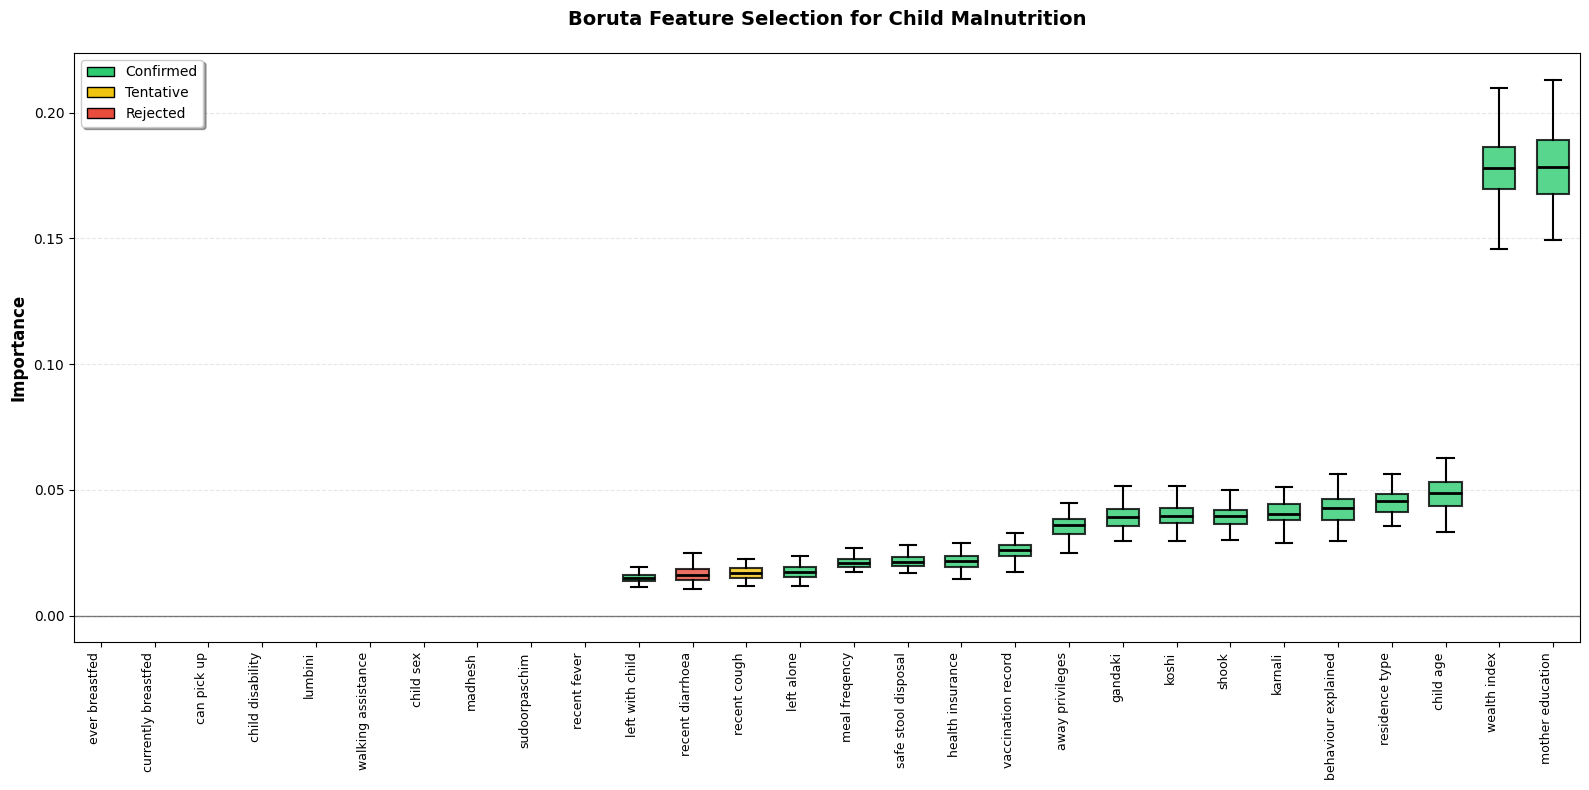

In [10]:
def create_boruta_boxplot(X_train, y_train, feature_names=None, max_depth=None, 
                          n_estimators='auto', max_iter=100, random_state=42,
                          figsize=(16, 8), save_path=None):
    
    # Convert to numpy if DataFrame
    if isinstance(X_train, pd.DataFrame):
        feature_names = X_train.columns.tolist()
        X_np = X_train.values
    else:
        X_np = X_train
        if feature_names is None:
            feature_names = [f"Feature_{i}" for i in range(X_np.shape[1])]
   
    y_np = y_train.values if isinstance(y, pd.Series) else y_train
    
    print("Running Boruta feature selection...")
    print(f"Features: {X_np.shape[1]}, Samples: {X_np.shape[0]}")
    
    # Initialize Random Forest
    rf = RandomForestClassifier(
        n_jobs=-1,
        class_weight='balanced',
        max_depth=max_depth,
        random_state=random_state
    )
    
    # Initialize and fit Boruta
    boruta_selector = BorutaPy(
        estimator=rf,
        n_estimators=n_estimators,
        verbose=0,
        random_state=random_state,
        max_iter=max_iter
    )
    
    boruta_selector.fit(X_np, y_np)
    
    print("\nBoruta selection completed!")
    print(f"Confirmed features: {boruta_selector.n_features_}")
    
    # Get feature importance history
    importance_history = boruta_selector.importance_history_
    
    # Determine feature status
    confirmed = boruta_selector.support_
    tentative = boruta_selector.support_weak_
    rejected = ~(confirmed | tentative)
    
    # Create DataFrame for plotting
    plot_data = []
    for i, feature in enumerate(feature_names):
        importances = importance_history[:, i]
        
        if confirmed[i]:
            status = 'Confirmed'
            color = '#2ecc71'  # Green
        elif tentative[i]:
            status = 'Tentative'
            color = '#f1c40f'  # Yellow
        else:
            status = 'Rejected'
            color = '#e74c3c'  # Red
        
        for imp in importances:
            plot_data.append({
                'Feature': feature,
                'Importance': imp,
                'Status': status,
                'Color': color,
                'Rank': boruta_selector.ranking_[i]
            })
    
    df_plot = pd.DataFrame(plot_data)
    
    # Sort features by median importance
    feature_order = df_plot.groupby('Feature')['Importance'].median().sort_values().index
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create boxplot data
    positions = []
    box_data = []
    colors = []
    labels = []
    
    for pos, feature in enumerate(feature_order):
        feature_data = df_plot[df_plot['Feature'] == feature]
        box_data.append(feature_data['Importance'].values)
        positions.append(pos)
        colors.append(feature_data['Color'].iloc[0])
        labels.append(feature)
    
    # Create boxplot
    bp = ax.boxplot(box_data, positions=positions, widths=0.6,
                    patch_artist=True, showfliers=False,
                    boxprops=dict(linewidth=1.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    medianprops=dict(linewidth=2, color='black'),
                    flierprops=dict(marker='o', markerfacecolor='white', 
                                   markersize=4, markeredgecolor='black',
                                   markeredgewidth=0.5))
    
    # Color boxes according to status
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    
    # Styling
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=9)
    ax.set_ylabel('Importance', fontweight='bold', fontsize=12)
    ax.set_title('Boruta Feature Selection for Child Malnutrition', 
                 fontweight='bold', fontsize=14, pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add horizontal line at y=0
    ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)
    
    # Create legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', edgecolor='black', label='Confirmed'),
        Patch(facecolor='#f1c40f', edgecolor='black', label='Tentative'),
        Patch(facecolor='#e74c3c', edgecolor='black', label='Rejected')
    ]
    ax.legend(handles=legend_elements, loc='upper left', 
             frameon=True, shadow=True, fontsize=10)
    
    # Add counts to legend
    n_confirmed = confirmed.sum()
    n_tentative = tentative.sum()
    n_rejected = rejected.sum()
    
    text_str = f'Confirmed: {n_confirmed}\nTentative: {n_tentative}\nRejected: {n_rejected}'
    ax.text(0.02, 0.98, text_str, transform=ax.transAxes,
           verticalalignment='top', bbox=dict(boxstyle='round', 
           facecolor='wheat', alpha=0.5), fontsize=9)
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nFigure saved to: {save_path}")
    
    return fig, boruta_selector


def create_boruta_summary_table(boruta_selector, feature_names):
    """
    Create a summary table of Boruta results.
    """
    results = pd.DataFrame({
        'Feature': feature_names,
        'Rank': boruta_selector.ranking_,
        'Confirmed': boruta_selector.support_,
        'Tentative': boruta_selector.support_weak_,
        'Status': ['Confirmed' if boruta_selector.support_[i] 
                   else 'Tentative' if boruta_selector.support_weak_[i]
                   else 'Rejected' for i in range(len(feature_names))]
    })
    
    results = results.sort_values('Rank')
    
    print("\n" + "="*70)
    print("BORUTA FEATURE SELECTION SUMMARY")
    print("="*70)
    print(results.to_string(index=False))
    print("="*70)
    print(f"\nTotal Features: {len(feature_names)}")
    print(f"Confirmed: {boruta_selector.support_.sum()}")
    print(f"Tentative: {boruta_selector.support_weak_.sum()}")
    print(f"Rejected: {(~(boruta_selector.support_ | boruta_selector.support_weak_)).sum()}")
    
    return results


def plot_boruta_feature_importance_comparison(boruta_selector, feature_names, 
                                              n_top=20, figsize=(10, 8)):
    """
    Create a horizontal bar plot comparing confirmed vs rejected features.
    """
    # Get median importance for each feature
    # importance_history = boruta_selector.importance_history_
    importance_history = boruta_selector.importance_history_
    if importance_history.shape[1] != len(feature_names):
        raise ValueError("Mismatch between importance history and feature names")

    median_importance = np.median(importance_history, axis=0)
    
    # Create DataFrame
    df_importance = pd.DataFrame({
        'Feature': feature_names,
        'Median_Importance': median_importance,
        'Status': ['Confirmed' if boruta_selector.support_[i] 
                   else 'Tentative' if boruta_selector.support_weak_[i]
                   else 'Rejected' for i in range(len(feature_names))],
        'Rank': boruta_selector.ranking_
    })
    
    # Sort by importance
    df_importance = df_importance.sort_values('Median_Importance', ascending=False)
    
    # Take top N
    df_top = df_importance.head(n_top)
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color mapping
    color_map = {'Confirmed': '#2ecc71', 'Tentative': '#f1c40f', 'Rejected': '#e74c3c'}
    colors = [color_map[status] for status in df_top['Status']]
    
    # Horizontal bar plot
    y_pos = np.arange(len(df_top))
    ax.barh(y_pos, df_top['Median_Importance'], color=colors, 
            edgecolor='black', linewidth=1)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_top['Feature'], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Median Feature Importance', fontweight='bold', fontsize=11)
    ax.set_title(f'Top {n_top} Features by Boruta Importance', 
                 fontweight='bold', fontsize=13, pad=15)
    ax.grid(axis='x', alpha=0.3)
    
    # Add legend
    legend_elements = [
        Patch(facecolor='#2ecc71', edgecolor='black', label='Confirmed'),
        Patch(facecolor='#f1c40f', edgecolor='black', label='Tentative'),
        Patch(facecolor='#e74c3c', edgecolor='black', label='Rejected')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, shadow=True)
    
    plt.tight_layout()
    return fig

# Bourta Visualizations and Summary
# 1. Create main Boruta boxplot
fig, boruta_selector = create_boruta_boxplot(
    X_train, 
    y_train, 
    max_depth=5,
    max_iter=100,
    random_state=42,
    figsize=(16, 8),
    save_path='boruta_feature_selection.png'
)

# 2. Create summary table
results_table = create_boruta_summary_table(boruta_selector, X_train.columns)

plt.show()

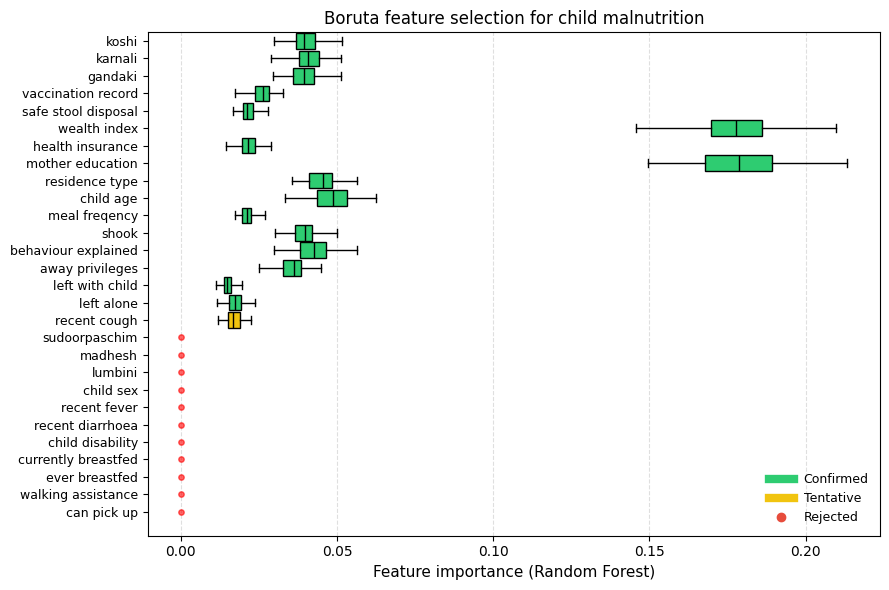

In [11]:
def plot_boruta_nature_style(boruta_selector, feature_names, figsize=(10, 7)):

    importance = boruta_selector.importance_history_
    confirmed = boruta_selector.support_
    tentative = boruta_selector.support_weak_
    rejected = ~(confirmed | tentative)

    # Build dataframe
    df = pd.DataFrame(
        importance,
        columns=feature_names
    ).melt(var_name='Feature', value_name='Importance')

    df['Status'] = df['Feature'].map({
        f: 'Confirmed' if confirmed[i]
        else 'Tentative' if tentative[i]
        else 'Rejected'
        for i, f in enumerate(feature_names)
    })

    # Sort by median importance
    order = (
        df.groupby('Feature')['Importance']
          .median()
          .sort_values()
          .index
    )

    fig, ax = plt.subplots(figsize=figsize)

    # --- Confirmed ---
    confirmed_data = [
        importance[:, i]
        for i, f in enumerate(feature_names)
        if confirmed[i]
    ]
    confirmed_labels = [
        f for i, f in enumerate(feature_names) if confirmed[i]
    ]

    # --- Tentative ---
    tentative_data = [
        importance[:, i]
        for i, f in enumerate(feature_names)
        if tentative[i]
    ]
    tentative_labels = [
        f for i, f in enumerate(feature_names) if tentative[i]
    ]

    # --- Rejected ---
    rejected_labels = [
        f for i, f in enumerate(feature_names) if rejected[i]
    ]

    y_pos = 0

    # Plot rejected (zero line)
    ax.scatter(
        np.zeros(len(rejected_labels)),
        np.arange(y_pos, y_pos + len(rejected_labels)),
        color='red',
        s=15,
        alpha=0.6,
        label='Rejected'
    )
    y_pos += len(rejected_labels)

    # Plot tentative
    if len(tentative_data) > 0:
        ax.boxplot(
            tentative_data,
            vert=False,
            positions=np.arange(y_pos, y_pos + len(tentative_data)),
            widths=0.9,
            patch_artist=True,
            boxprops=dict(facecolor='#f1c40f', edgecolor='black'),
            medianprops=dict(color='black'),
            showfliers=False
        )
        y_pos += len(tentative_data)

    # Plot confirmed
    if len(confirmed_data) > 0:
        ax.boxplot(
            confirmed_data,
            vert=False,
            positions=np.arange(y_pos, y_pos + len(confirmed_data)),
            widths=0.9,
            patch_artist=True,
            boxprops=dict(facecolor='#2ecc71', edgecolor='black'),
            medianprops=dict(color='black'),
            showfliers=False
        )
        y_pos += len(confirmed_data)


    # Y-axis labels
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(
        rejected_labels + tentative_labels + confirmed_labels,
        fontsize=9
    )

    ax.set_xlabel("Feature importance (Random Forest)", fontsize=11)
    ax.set_title("Boruta feature selection for child malnutrition", fontsize=12)

    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    # Minimal legend
    ax.legend(
        handles=[
            plt.Line2D([0], [0], color='#2ecc71', lw=6, label='Confirmed'),
            plt.Line2D([0], [0], color='#f1c40f', lw=6, label='Tentative'),
            plt.Line2D([0], [0], marker='o', color='#e74c3c', lw=0, label='Rejected')
        ],
        frameon=False,
        fontsize=9,
        loc='lower right'
    )

    plt.tight_layout()
    return fig

fig = plot_boruta_nature_style(
    boruta_selector,
    X_train.columns,
    figsize=(9, 6)
)

fig.savefig(
    "boruta_nature_style.png",
    dpi=600,
    bbox_inches="tight"
)

### Correlation

              Feature_1            Feature_2  Correlation
0           can pick up       ever breastfed    -0.961171
8        ever breastfed  currently breastfed     0.960148
5    walking assistance     child disability     0.938916
11       ever breastfed   vaccination record     0.916608
3           can pick up  safe stool disposal    -0.914538
4           can pick up   vaccination record    -0.909385
10       ever breastfed  safe stool disposal     0.906006
1           can pick up  currently breastfed    -0.886042
9        ever breastfed            child age    -0.873130
18  safe stool disposal   vaccination record     0.867941
14  currently breastfed   vaccination record     0.862939
2           can pick up            child age     0.853209
17            child age   vaccination record    -0.850738
12  currently breastfed            child age    -0.847568
16     child disability            child age     0.837794
13  currently breastfed  safe stool disposal     0.826290
15     child d

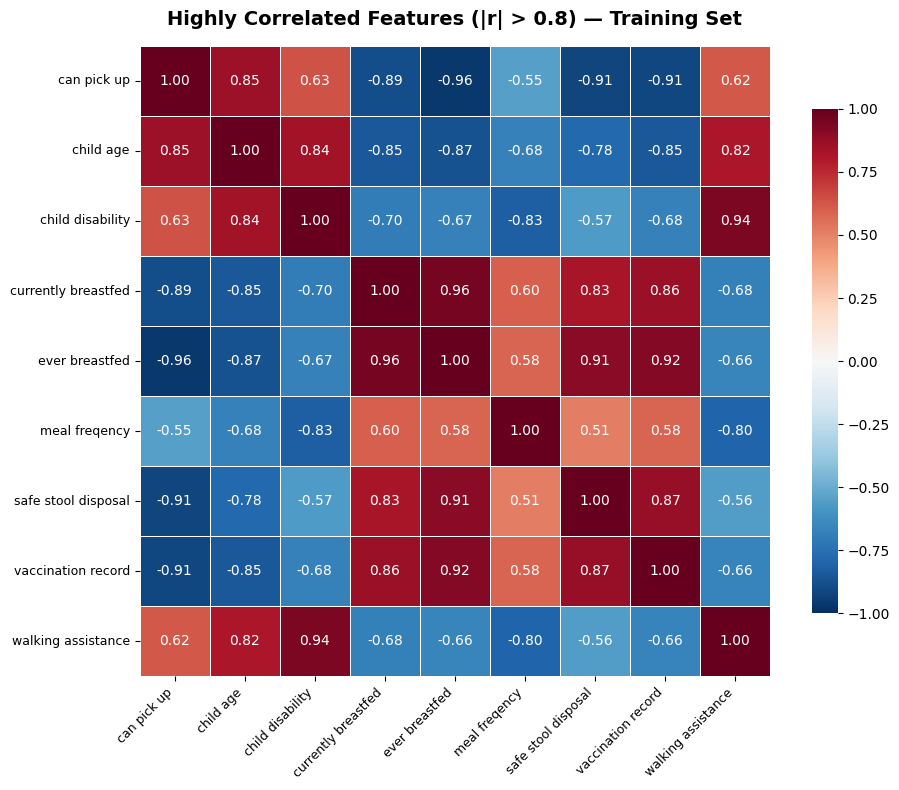

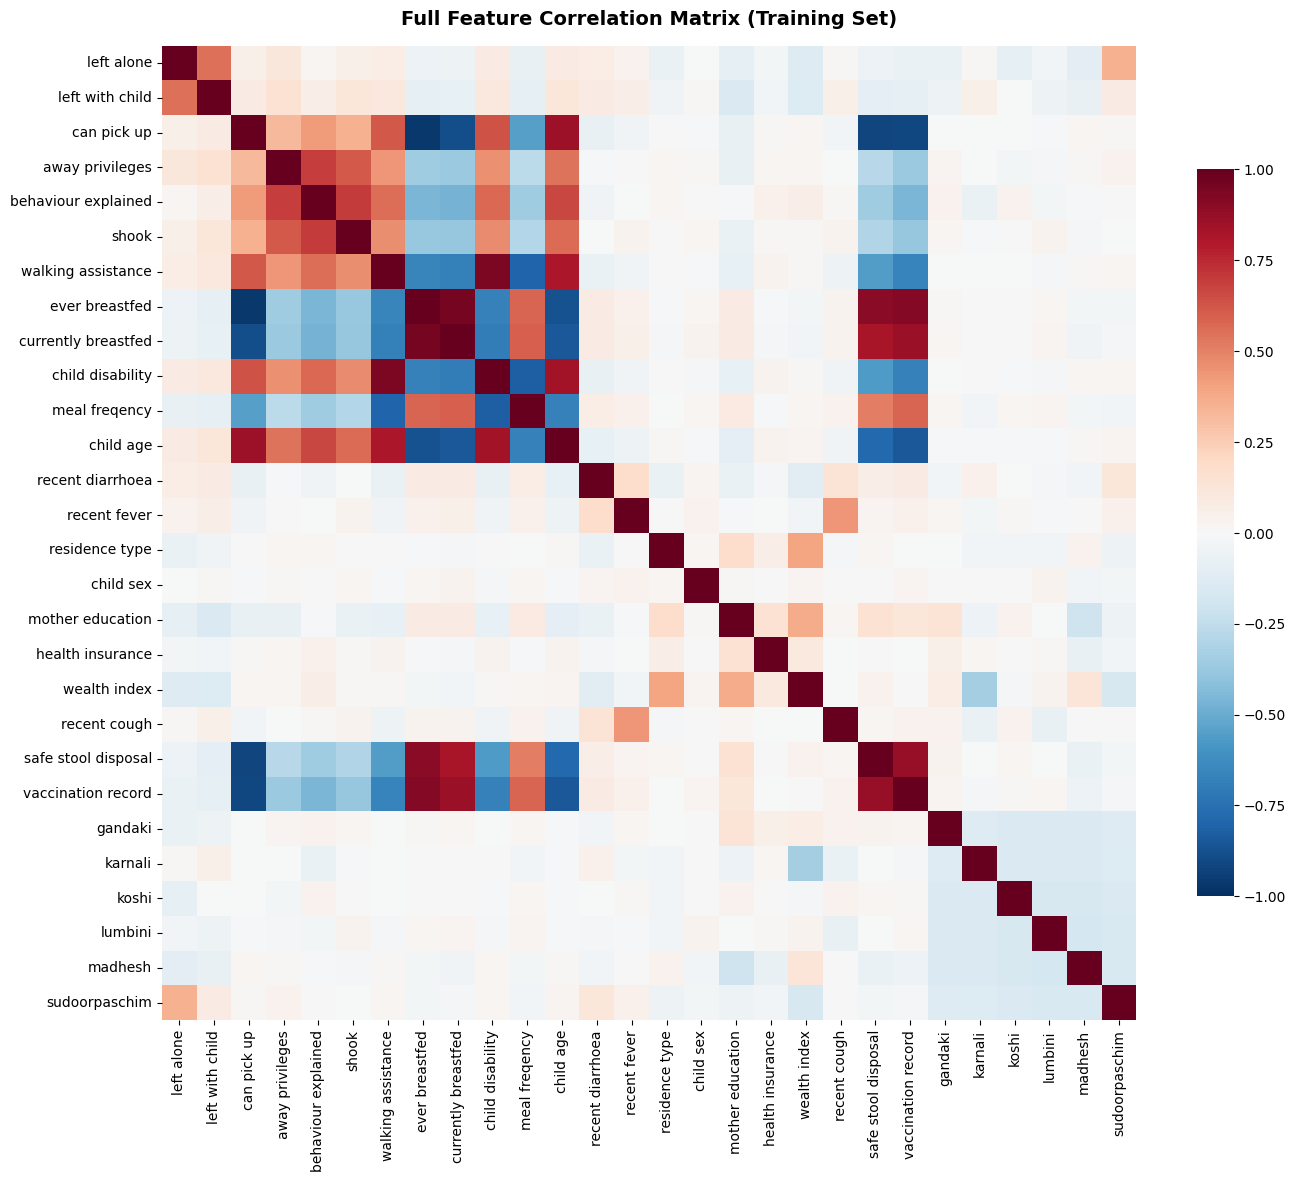

In [12]:
threshold = 0.8
corr_matrix = X_train.corr()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > threshold:
            high_corr_pairs.append({
                "Feature_1": corr_matrix.columns[i],
                "Feature_2": corr_matrix.columns[j],
                "Correlation": corr_val
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
    "Correlation", key=abs, ascending=False
)

print(high_corr_df)

# ===============================
# HEATMAP
# ===============================

if high_corr_df.empty:
    print(f"No feature pairs with |correlation| > {threshold}")
else:
    # Get unique features involved in high correlations
    high_corr_features = sorted(
        set(high_corr_df['Feature_1']).union(high_corr_df['Feature_2'])
    )

    # Subset correlation matrix
    high_corr_matrix = corr_matrix.loc[high_corr_features, high_corr_features]

    # Highly Correlated Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        high_corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )

    plt.title(
        f"Highly Correlated Features (|r| > {threshold}) — Training Set",
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

# Full Plot
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.title(
    "Full Feature Correlation Matrix (Training Set)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

“A correlation heatmap was generated using the training data to visualize pairs of features with absolute Pearson correlation greater than 0.8, identifying potential sources of multicollinearity prior to model training.”

### VIF

                Feature        VIF
7        ever breastfed  57.184958
2           can pick up  19.642036
8   currently breastfed  19.136589
11            child age  13.256269
9      child disability  11.699615
6    walking assistance   8.994701
20  safe stool disposal   7.657625
21   vaccination record   7.574676
10        meal freqency   3.559474
4   behaviour explained   3.311195
5                 shook   2.196784
3       away privileges   2.162346
18         wealth index   1.701698
0            left alone   1.681813
27        sudoorpaschim   1.681799
23              karnali   1.651712
26              madhesh   1.580869
1       left with child   1.547208
25              lumbini   1.506893
24                koshi   1.470772
22              gandaki   1.376145
16     mother education   1.348324
13         recent fever   1.286332
19         recent cough   1.280931
14       residence type   1.217125
12     recent diarrhoea   1.082840
17     health insurance   1.041052
15            child 

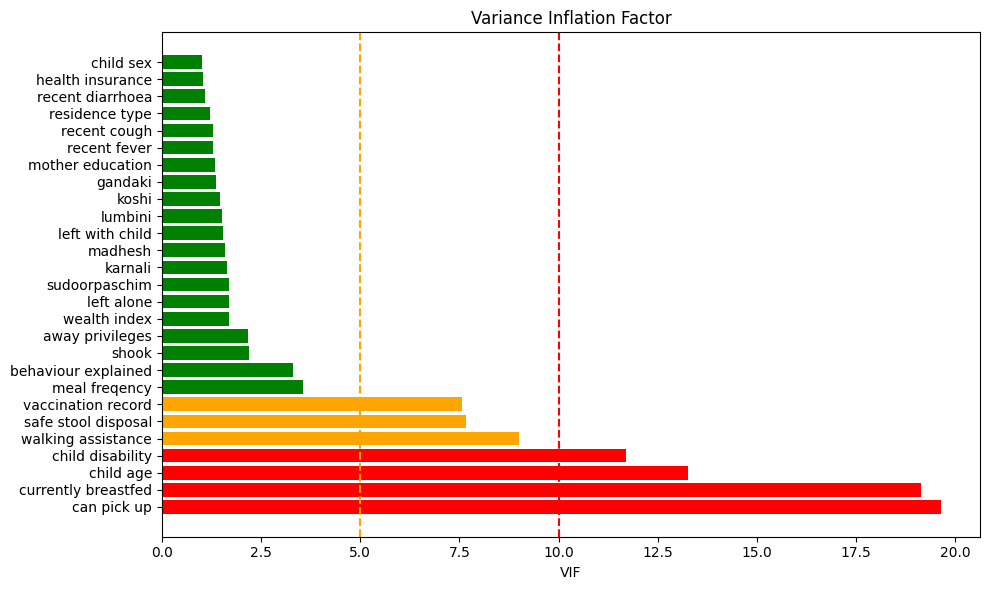

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_threshold = 10

X_numeric = X_train.select_dtypes(include=[np.number])
X_numeric = X_numeric.loc[:, X_numeric.var() > 0]  # drop constants

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_numeric)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_scaled, i)
    for i in range(X_train_scaled.shape[1])
]

vif_data["VIF"] = vif_data["VIF"].replace([np.inf], np.nan)
vif_data = vif_data.sort_values("VIF", ascending=False)

print(vif_data)

# VIF Plot
plt.figure(figsize=(10, 6))
plot_vif = vif_data[vif_data["VIF"] < 50]

colors = ["red" if v > 10 else "orange" if v > 5 else "green" for v in plot_vif["VIF"]]
plt.barh(plot_vif["Feature"], plot_vif["VIF"], color=colors)

plt.axvline(10, color="red", linestyle="--")
plt.axvline(5, color="orange", linestyle="--")

plt.xlabel("VIF")
plt.title("Variance Inflation Factor")
plt.tight_layout()
plt.savefig("vif_plot.png", dpi=300)
plt.show()


In [14]:
# Final data with selected features
final_features = df_final[['mother education', 'wealth index',  'gandaki', 'koshi', 'vaccination record',  'child age', 'health insurance', 'residence type',  'karnali', 
                           'meal freqency', 'safe stool disposal',  'away privileges', 'left alone', 'recent diarrhoea', 'recent cough', 'sudoorpaschim']]
final_response = df_final['malnutrition']

# Final dataset
data = final_features.copy()
data['malnutrition'] = final_response

# Save to csv
data.to_csv('data.csv', index = False)
data.head()

,mother education,wealth index,gandaki,koshi,vaccination record,child age,health insurance,residence type,karnali,meal freqency,safe stool disposal,away privileges,left alone,recent diarrhoea,recent cough,sudoorpaschim,malnutrition
0,2.0,1,0,1,1,1.0,0.0,0,0,7.0,1,0,0.0,0.0,0.0,0,1
1,2.0,1,0,1,-1,3.0,0.0,0,0,-1.0,-1,0,0.0,0.0,1.0,0,1
2,1.0,1,0,1,0,2.0,0.0,0,0,-1.0,1,0,4.0,1.0,0.0,0,0
3,1.0,1,0,1,1,1.0,0.0,0,0,5.0,1,0,0.0,1.0,0.0,0,0
4,1.0,1,0,1,-1,4.0,0.0,0,0,-1.0,-1,1,0.0,0.0,1.0,0,0


In [ ]:
X_final = df_final[['mother education', 'wealth index', 'gandaki', 'koshi', 'vaccination record', 'child age', 'health insurance', 
                 'residence type', 'karnali', 'meal freqency', 'safe stool disposal', 'away privileges', 'left alone']]

# Final Features
# X_final = df_final[['mother education', 'wealth index',  'Gandaki', 'Koshi', 'vaccination record',  'child age', 'health insurance', 'residence type',  'Karnali', 
#              'meal freqency', 'safe stool disposal',  'away privileges', 'left alone', 'behaviour explained', 'shook', 'recent cough', 'recent diarrhoea', 'Sudoorpaschim']]
y_final = df_final['malnutrition']

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

# ============================================================================
# STEP 2: Feature Scaling (for distance-based algorithms)
# ============================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================================
# STEP 3: Define Models with Initial Parameters
# ============================================================================
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        random_state=42,
        class_weight='balanced'  # Handle class imbalance
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
    'LDA': LinearDiscriminantAnalysis(),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        class_weight='balanced'
    ),
    'SVM': SVC(
        kernel='rbf',
        probability=True,
        random_state=42,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='logloss'
    )
}

# Models that need scaling
needs_scaling = ['Logistic Regression', 'KNN', 'LDA', 'SVM']

# ============================================================================
# STEP 4: Train Models and Collect Results
# ============================================================================
results = []
trained_models = {}

print("\n" + "="*80)
print("TRAINING AND EVALUATING MODELS")
print("="*80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled or unscaled data
    if name in needs_scaling:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test
    
    # Train model
    model.fit(X_tr, y_train)
    
    # Predictions
    y_pred = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    average_precision = average_precision_score(y_test, y_pred_proba)
    cohen_kappa = cohen_kappa_score(y_test, y_pred)

    # ROC-AUC (if binary classification)
    if len(np.unique(y_final)) == 2 and y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None
    
    # Cross-validation score
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'CV Mean': cv_mean,
        'CV Std': cv_std,
        'Average Precision': average_precision,
        'Cohen Kappa': cohen_kappa
    })
    
    trained_models[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  CV Score: {cv_mean:.4f} (+/- {cv_std:.4f})")

# ============================================================================
# STEP 5: Results Summary
# ============================================================================
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
print(results_df.to_string(index=False))

Training set size: 5132
Test set size: 1284

Class distribution in training set:
malnutrition
0    0.572097
1    0.427903
Name: proportion, dtype: float64

TRAINING AND EVALUATING MODELS

Training Logistic Regression...
  Accuracy: 0.5997
  F1-Score: 0.6018
  CV Score: 0.5972 (+/- 0.0088)

Training KNN...
  Accuracy: 0.5903
  F1-Score: 0.5857
  CV Score: 0.5573 (+/- 0.0110)

Training LDA...
  Accuracy: 0.6192
  F1-Score: 0.6044
  CV Score: 0.6118 (+/- 0.0051)

Training Decision Tree...
  Accuracy: 0.5857
  F1-Score: 0.5875
  CV Score: 0.5647 (+/- 0.0076)

Training Random Forest...
  Accuracy: 0.6005
  F1-Score: 0.6025
  CV Score: 0.5881 (+/- 0.0076)

Training SVM...
  Accuracy: 0.6083
  F1-Score: 0.6102
  CV Score: 0.5947 (+/- 0.0131)

Training XGBoost...
  Accuracy: 0.5974
  F1-Score: 0.5875
  CV Score: 0.5922 (+/- 0.0086)

MODEL COMPARISON RESULTS
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV Mean   CV Std  Average Precision  Cohen Kappa
                LDA

In [16]:
X_final.shape

(6416, 13)

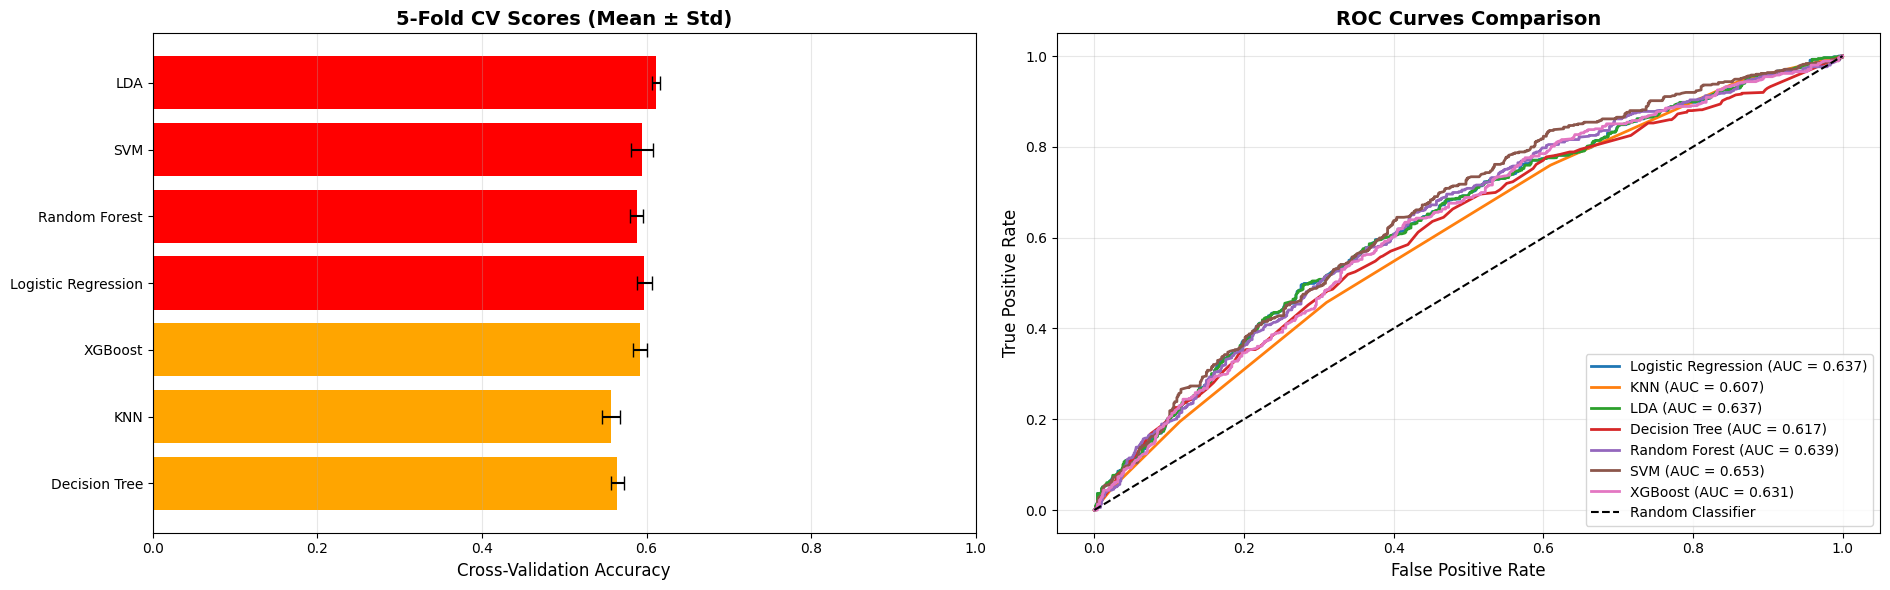


DETAILED CLASSIFICATION REPORT - LDA
              precision    recall  f1-score   support

           0       0.64      0.78      0.70       735
           1       0.58      0.40      0.47       549

    accuracy                           0.62      1284
   macro avg       0.61      0.59      0.59      1284
weighted avg       0.61      0.62      0.60      1284


ANALYSIS COMPLETE!

Best Model: LDA
Best Accuracy: 0.6192
Best F1-Score: 0.6044


In [17]:

# ============================================================================
# STEP 6: Visualization
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(19, 6))

# -----------------------------
# Cross-validation accuracy bar chart (left subplot)
# -----------------------------
ax1 = axes[0]

ax1.barh(results_df['Model'], results_df['CV Mean'], 
         xerr=results_df['CV Std'], color=colors, capsize=5)
ax1.set_xlabel('Cross-Validation Accuracy', fontsize=12)
ax1.set_title('5-Fold CV Scores (Mean ± Std)', fontsize=14, fontweight='bold')
ax1.set_xlim([0, 1])
ax1.invert_yaxis()  # Optional: highest accuracy on top
ax1.grid(alpha=0.3, axis='x')

# -----------------------------
# ROC curves (right subplot)
# -----------------------------
ax2 = axes[1]

# Only plot if binary classification
if len(np.unique(y_final)) == 2:
    for name, model_info in trained_models.items():
        probs = model_info['probabilities']
        if probs is not None:
            # Ensure probs is for positive class
            if probs.ndim == 2 and probs.shape[1] == 2:
                probs = probs[:, 1]
            fpr, tpr, _ = roc_curve(y_test, probs)
            auc = roc_auc_score(y_test, probs)
            ax2.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
    
    # Random classifier
    ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
    ax2.legend(loc='lower right', fontsize=10)
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================================
# Detailed Classification Report for Best Model
# ============================================================================
best_model_name = results_df.iloc[0]['Model']
best_predictions = trained_models[best_model_name]['predictions']

print("\n" + "="*80)
print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")
print("="*80)
print(classification_report(y_test, best_predictions))

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"Best F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")

___

# ML Models Comparison for Malnutrition Prediction

Training set size: 5132
Test set size: 1284

Class distribution in training set:
malnutrition
0    0.572097
1    0.427903
Name: proportion, dtype: float64

TRAINING AND EVALUATING MODELS

Training Logistic Regression...
  Accuracy: 0.5997
  F1-Score: 0.6018
  CV Score: 0.5972 (+/- 0.0088)

Training KNN...


  Accuracy: 0.5903
  F1-Score: 0.5857
  CV Score: 0.5573 (+/- 0.0110)

Training LDA...
  Accuracy: 0.6192
  F1-Score: 0.6044
  CV Score: 0.6118 (+/- 0.0051)

Training Decision Tree...
  Accuracy: 0.5857
  F1-Score: 0.5875
  CV Score: 0.5647 (+/- 0.0076)

Training Random Forest...
  Accuracy: 0.6005
  F1-Score: 0.6025
  CV Score: 0.5881 (+/- 0.0076)

Training SVM...
  Accuracy: 0.6083
  F1-Score: 0.6102
  CV Score: 0.5947 (+/- 0.0131)

Training XGBoost...
  Accuracy: 0.5974
  F1-Score: 0.5875
  CV Score: 0.5922 (+/- 0.0086)

MODEL COMPARISON RESULTS
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV Mean   CV Std
                LDA  0.619159   0.611637 0.619159  0.604428 0.636870 0.611848 0.005076
                SVM  0.608255   0.622212 0.608255  0.610179 0.652872 0.594697 0.013133
      Random Forest  0.600467   0.608106 0.600467  0.602462 0.638753 0.588077 0.007572
Logistic Regression  0.599688   0.609777 0.599688  0.601798 0.637308 0.597231 0.008819
          

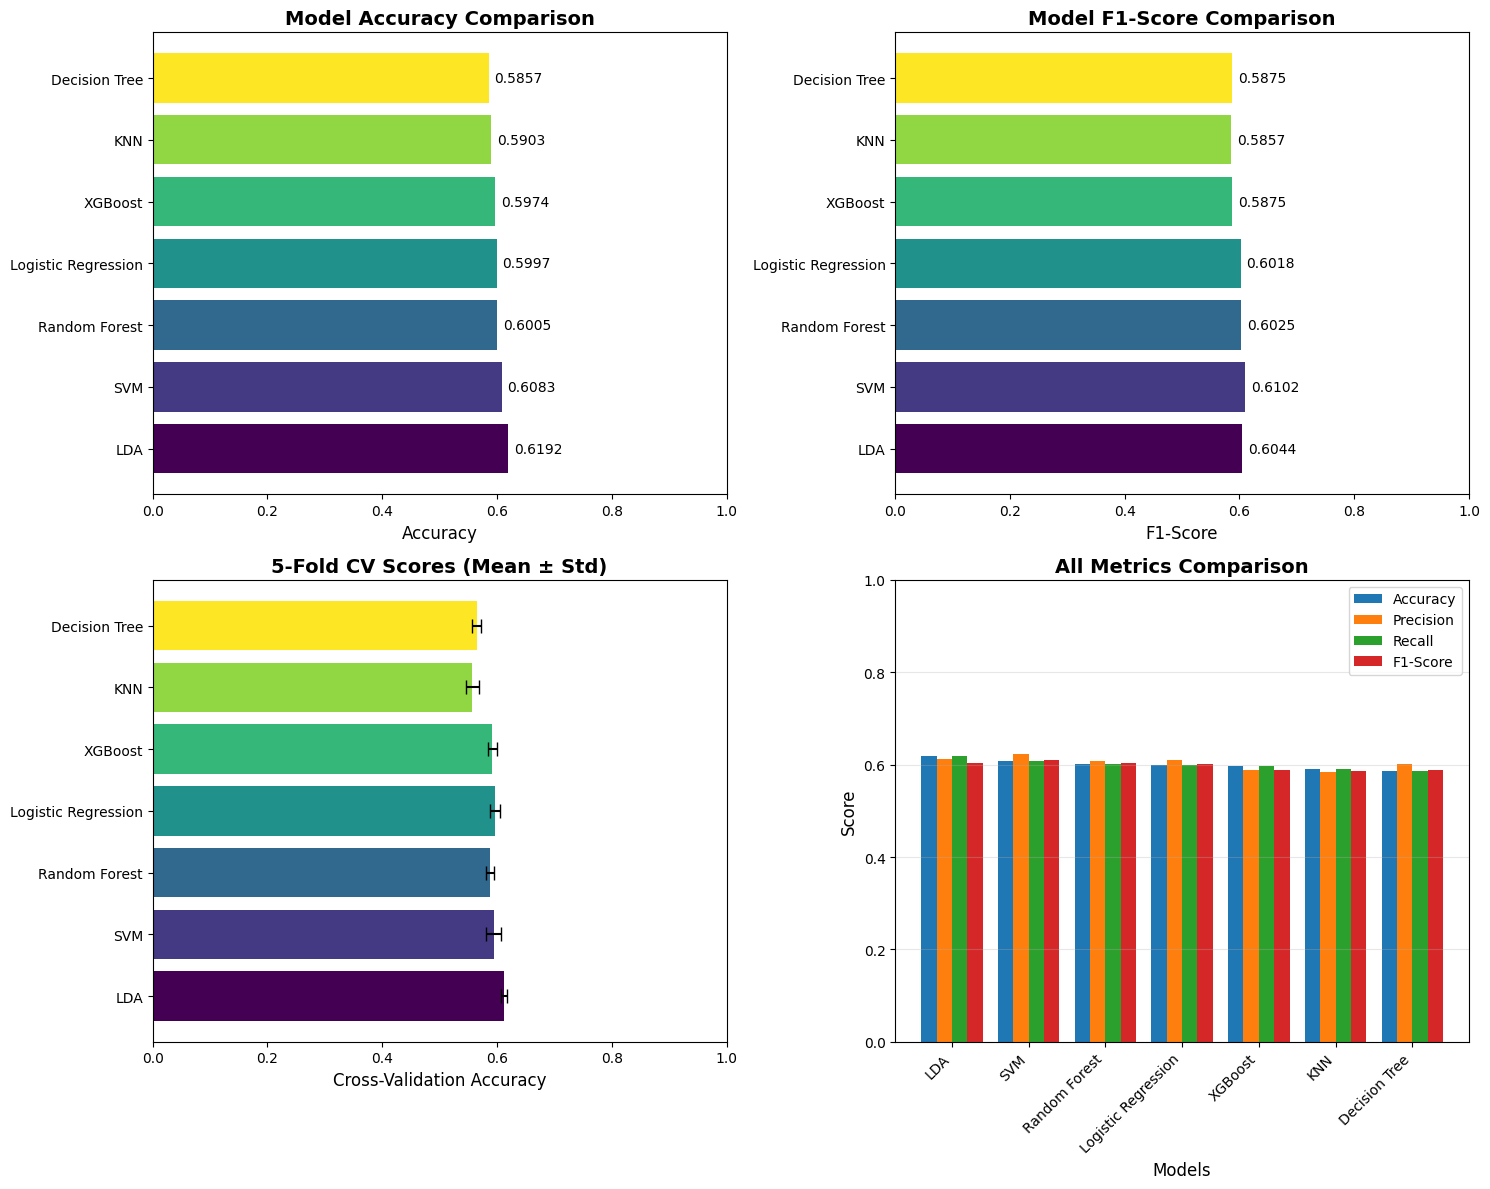

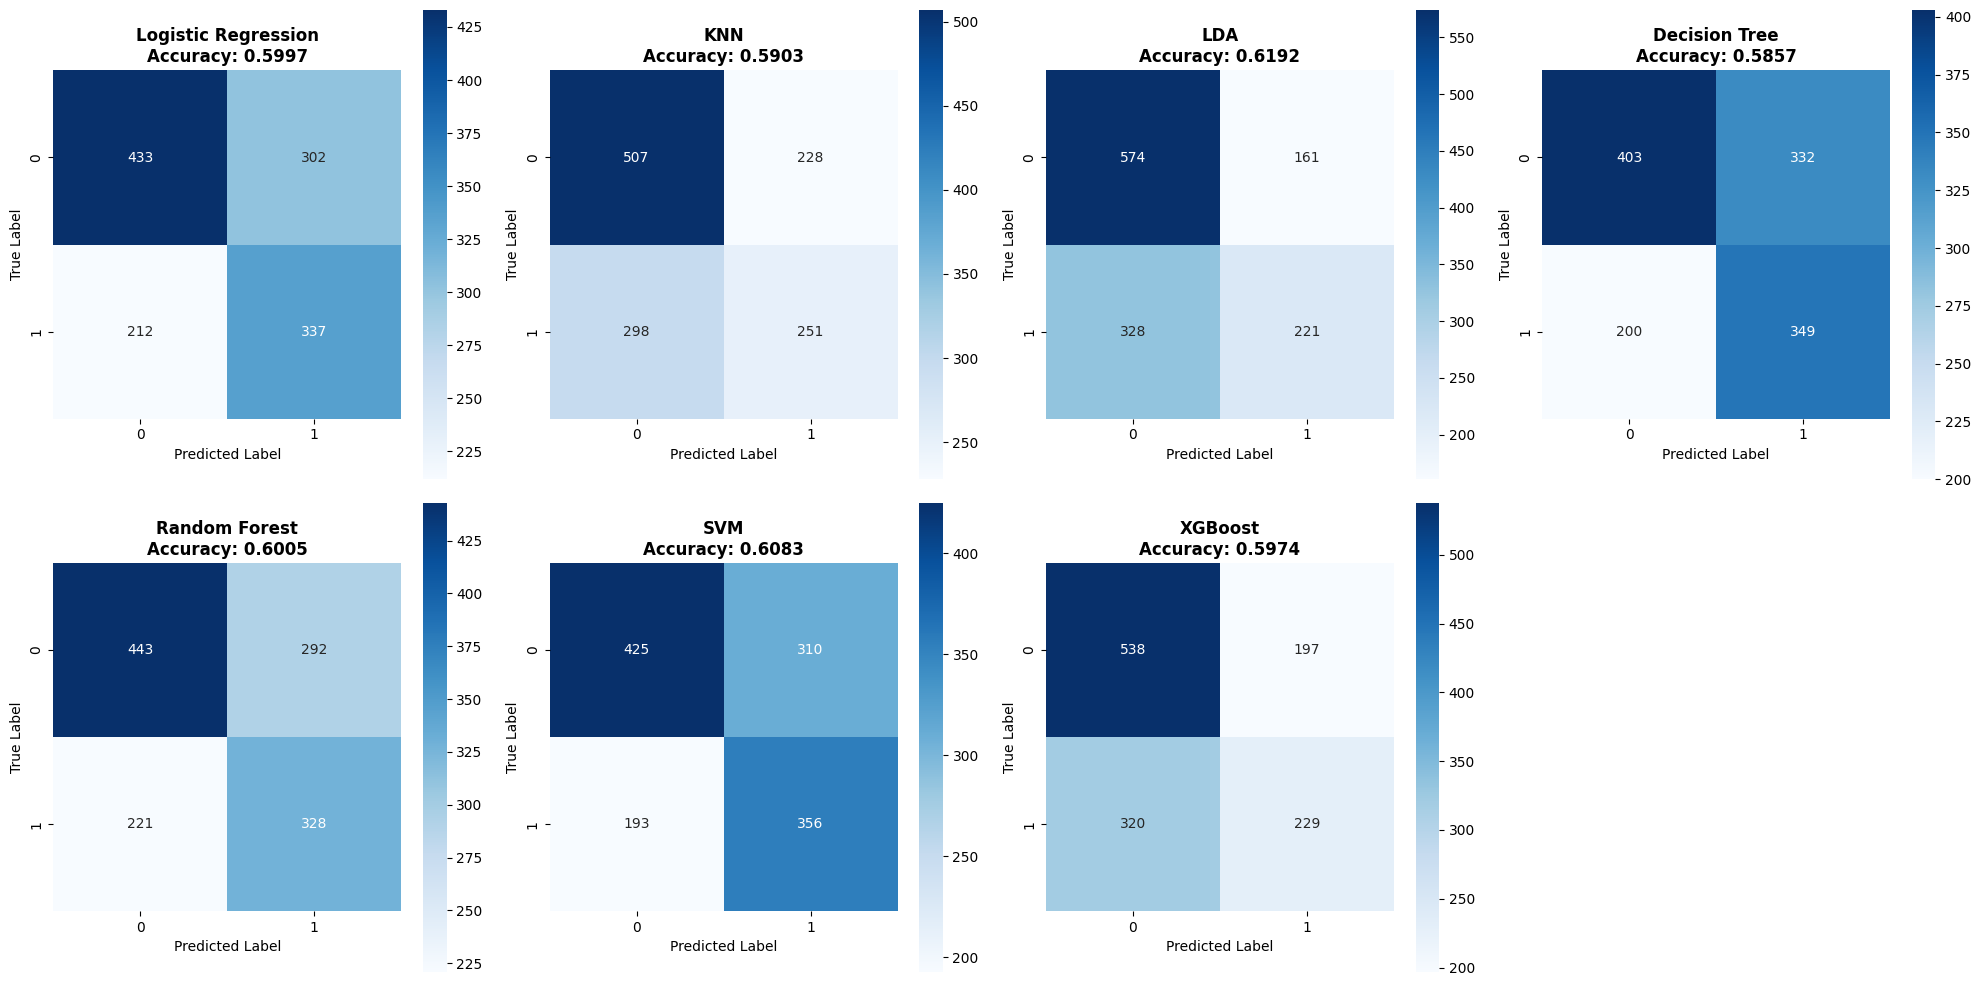

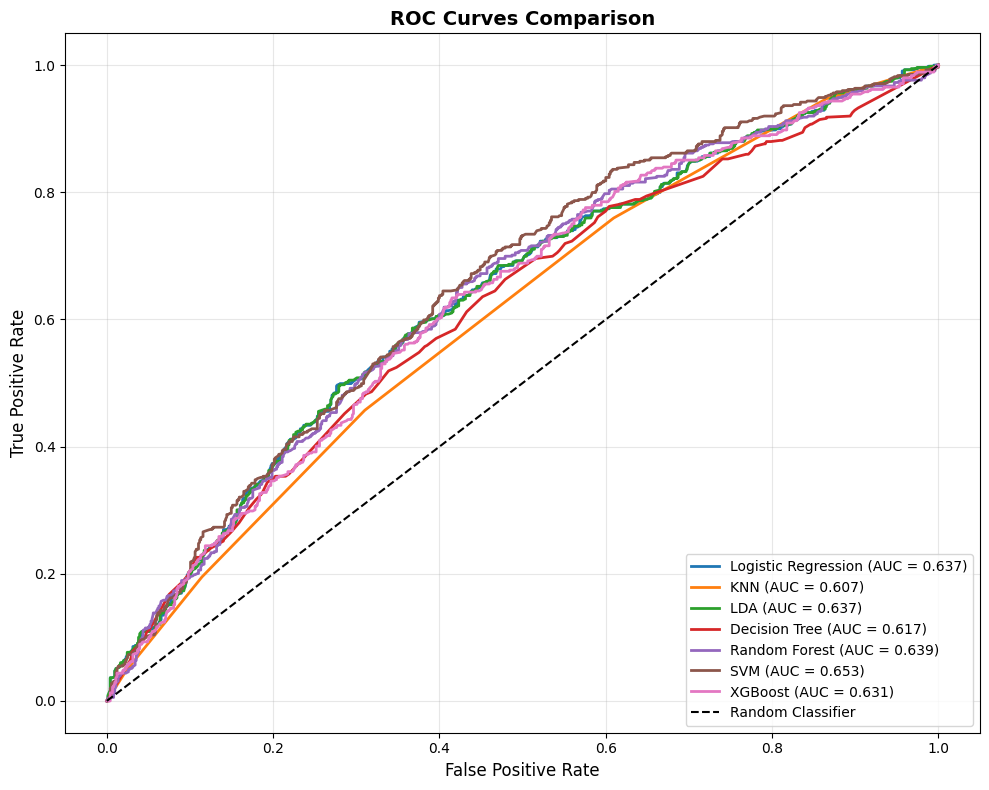


DETAILED CLASSIFICATION REPORT - LDA
              precision    recall  f1-score   support

           0       0.64      0.78      0.70       735
           1       0.58      0.40      0.47       549

    accuracy                           0.62      1284
   macro avg       0.61      0.59      0.59      1284
weighted avg       0.61      0.62      0.60      1284



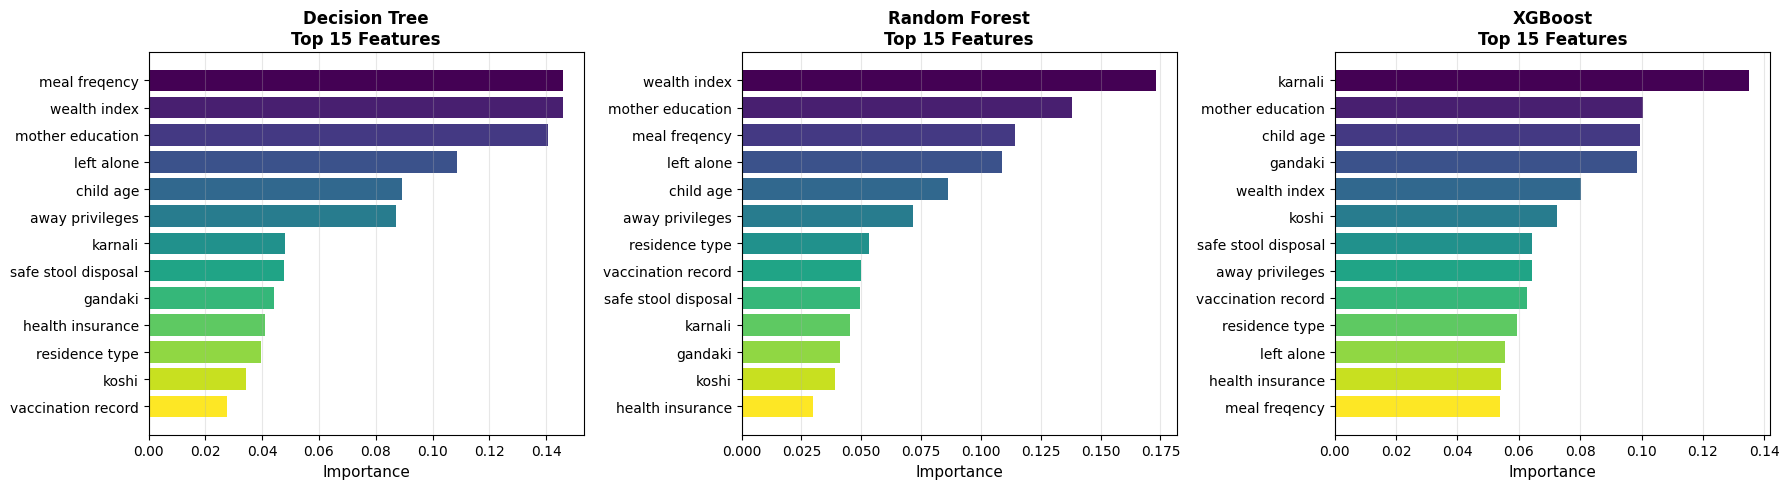


ANALYSIS COMPLETE!

Best Model: LDA
Best Accuracy: 0.6192
Best F1-Score: 0.6044


In [18]:
# ============================================================================
# STEP 1: Train-Test Split with Stratification
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

# ============================================================================
# STEP 2: Feature Scaling (for distance-based algorithms)
# ============================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================================
# STEP 3: Define Models with Initial Parameters
# ============================================================================
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        random_state=42,
        class_weight='balanced'  # Handle class imbalance
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
    'LDA': LinearDiscriminantAnalysis(),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        class_weight='balanced'
    ),
    'SVM': SVC(
        kernel='rbf',
        probability=True,
        random_state=42,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='logloss'
    )
}

# Models that need scaling
needs_scaling = ['Logistic Regression', 'KNN', 'LDA', 'SVM']

# ============================================================================
# STEP 4: Train Models and Collect Results
# ============================================================================
results = []
trained_models = {}

print("\n" + "="*80)
print("TRAINING AND EVALUATING MODELS")
print("="*80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled or unscaled data
    if name in needs_scaling:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test
    
    # Train model
    model.fit(X_tr, y_train)
    
    # Predictions
    y_pred = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # ROC-AUC (if binary classification)
    if len(np.unique(y_final)) == 2 and y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None
    
    # Cross-validation score
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'CV Mean': cv_mean,
        'CV Std': cv_std
    })
    
    trained_models[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  CV Score: {cv_mean:.4f} (+/- {cv_std:.4f})")

# ============================================================================
# STEP 5: Results Summary
# ============================================================================
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
print(results_df.to_string(index=False))

# ============================================================================
# STEP 6: Visualization
# ============================================================================

# 6.1: Accuracy Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy
ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
bars = ax1.barh(results_df['Model'], results_df['Accuracy'], color=colors)
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xlim([0, 1])
for i, (bar, acc) in enumerate(zip(bars, results_df['Accuracy'])):
    ax1.text(acc + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{acc:.4f}', va='center', fontsize=10)

# F1-Score
ax2 = axes[0, 1]
bars = ax2.barh(results_df['Model'], results_df['F1-Score'], color=colors)
ax2.set_xlabel('F1-Score', fontsize=12)
ax2.set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
ax2.set_xlim([0, 1])
for i, (bar, f1) in enumerate(zip(bars, results_df['F1-Score'])):
    ax2.text(f1 + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{f1:.4f}', va='center', fontsize=10)

# Cross-validation scores with error bars
ax3 = axes[1, 0]
ax3.barh(results_df['Model'], results_df['CV Mean'], 
         xerr=results_df['CV Std'], color=colors, capsize=5)
ax3.set_xlabel('Cross-Validation Accuracy', fontsize=12)
ax3.set_title('5-Fold CV Scores (Mean ± Std)', fontsize=14, fontweight='bold')
ax3.set_xlim([0, 1])

# All metrics comparison
ax4 = axes[1, 1]
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    ax4.bar(x + i*width, results_df[metric], width, label=metric)

ax4.set_xlabel('Models', fontsize=12)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax4.legend()
ax4.set_ylim([0, 1])
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 6.2: Confusion Matrices
n_models = len(trained_models)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, model_info) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, model_info['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar=True, square=True)
    axes[idx].set_title(f'{name}\nAccuracy: {results_df[results_df["Model"]==name]["Accuracy"].values[0]:.4f}',
                       fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

# Hide extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# 6.3: ROC Curves (if binary classification)
if len(np.unique(y_final)) == 2:
    plt.figure(figsize=(10, 8))
    
    for name, model_info in trained_models.items():
        if model_info['probabilities'] is not None:
            fpr, tpr, _ = roc_curve(y_test, model_info['probabilities'])
            auc = roc_auc_score(y_test, model_info['probabilities'])
            plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================================
# STEP 7: Detailed Classification Report for Best Model
# ============================================================================
best_model_name = results_df.iloc[0]['Model']
best_predictions = trained_models[best_model_name]['predictions']

print("\n" + "="*80)
print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")
print("="*80)
print(classification_report(y_test, best_predictions))

# ============================================================================
# STEP 8: Feature Importance (for tree-based models)
# ============================================================================
feature_importance_models = ['Decision Tree', 'Random Forest', 'XGBoost']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, name in enumerate(feature_importance_models):
    if name in trained_models:
        model = trained_models[name]['model']
        importances = model.feature_importances_
        
        # Create dataframe
        feat_imp_df = pd.DataFrame({
            'Feature': X_final.columns,
            'Importance': importances
        }).sort_values('Importance', ascending=False).head(15)
        
        # Plot
        axes[idx].barh(feat_imp_df['Feature'], feat_imp_df['Importance'], 
                      color=plt.cm.viridis(np.linspace(0, 1, len(feat_imp_df))))
        axes[idx].set_xlabel('Importance', fontsize=11)
        axes[idx].set_title(f'{name}\nTop 15 Features', fontsize=12, fontweight='bold')
        axes[idx].invert_yaxis()
        axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"Best F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")

# Hyperparameter Tuning for All Models

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# HYPERPARAMETER TUNING FOR ALL MODELS
# ============================================================================

# Assuming X_train, X_test, y_train, y_test are already defined
# And X_train_scaled, X_test_scaled for scaled versions

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================================
# 1. LOGISTIC REGRESSION
# ============================================================================
print("="*80)
print("1. TUNING LOGISTIC REGRESSION")
print("="*80)

lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000],
    'class_weight': ['balanced', None]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {lr_grid.best_params_}")
print(f"Best CV Score: {lr_grid.best_score_:.4f}")
print(f"Test Accuracy: {lr_grid.score(X_test_scaled, y_test):.4f}")

best_lr = lr_grid.best_estimator_

# ============================================================================
# 2. K-NEAREST NEIGHBORS
# ============================================================================
print("\n" + "="*80)
print("2. TUNING K-NEAREST NEIGHBORS")
print("="*80)

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {knn_grid.best_params_}")
print(f"Best CV Score: {knn_grid.best_score_:.4f}")
print(f"Test Accuracy: {knn_grid.score(X_test_scaled, y_test):.4f}")

best_knn = knn_grid.best_estimator_

# ============================================================================
# 3. LINEAR DISCRIMINANT ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("3. TUNING LINEAR DISCRIMINANT ANALYSIS")
print("="*80)

lda_params = {
    'solver': ['svd', 'lsqr', 'eigen'],
    'shrinkage': [None, 'auto', 0.1, 0.5, 0.9]
}

# Remove incompatible combinations
lda_grid = GridSearchCV(
    LinearDiscriminantAnalysis(),
    lda_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

lda_grid.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {lda_grid.best_params_}")
print(f"Best CV Score: {lda_grid.best_score_:.4f}")
print(f"Test Accuracy: {lda_grid.score(X_test_scaled, y_test):.4f}")

best_lda = lda_grid.best_estimator_

# ============================================================================
# 4. DECISION TREE
# ============================================================================
print("\n" + "="*80)
print("4. TUNING DECISION TREE")
print("="*80)

dt_params = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None],
    'max_features': ['sqrt', 'log2', None]
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    n_iter=50,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

dt_random.fit(X_train, y_train)

print(f"\nBest Parameters: {dt_random.best_params_}")
print(f"Best CV Score: {dt_random.best_score_:.4f}")
print(f"Test Accuracy: {dt_random.score(X_test, y_test):.4f}")

best_dt = dt_random.best_estimator_

# ============================================================================
# 5. RANDOM FOREST
# ============================================================================
print("\n" + "="*80)
print("5. TUNING RANDOM FOREST")
print("="*80)

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'bootstrap': [True, False]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=50,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_random.fit(X_train, y_train)

print(f"\nBest Parameters: {rf_random.best_params_}")
print(f"Best CV Score: {rf_random.best_score_:.4f}")
print(f"Test Accuracy: {rf_random.score(X_test, y_test):.4f}")

best_rf = rf_random.best_estimator_

# ============================================================================
# 6. SUPPORT VECTOR MACHINE
# ============================================================================
print("\n" + "="*80)
print("6. TUNING SUPPORT VECTOR MACHINE")
print("="*80)

svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'class_weight': ['balanced', None],
    'degree': [2, 3, 4]  # For poly kernel
}

svm_random = RandomizedSearchCV(
    SVC(probability=True, random_state=42),
    svm_params,
    n_iter=30,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

svm_random.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {svm_random.best_params_}")
print(f"Best CV Score: {svm_random.best_score_:.4f}")
print(f"Test Accuracy: {svm_random.score(X_test_scaled, y_test):.4f}")

best_svm = svm_random.best_estimator_

# ============================================================================
# 7. XGBOOST
# ============================================================================
print("\n" + "="*80)
print("7. TUNING XGBOOST")
print("="*80)

xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0, 0.1, 0.5, 1]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    n_iter=50,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random.fit(X_train, y_train)

print(f"\nBest Parameters: {xgb_random.best_params_}")
print(f"Best CV Score: {xgb_random.best_score_:.4f}")
print(f"Test Accuracy: {xgb_random.score(X_test, y_test):.4f}")

best_xgb = xgb_random.best_estimator_

# ============================================================================
# COMPARE TUNED MODELS
# ============================================================================
print("\n" + "="*80)
print("TUNED MODELS COMPARISON")
print("="*80)

tuned_models = {
    'Logistic Regression': (best_lr, X_test_scaled),
    'KNN': (best_knn, X_test_scaled),
    'LDA': (best_lda, X_test_scaled),
    'Decision Tree': (best_dt, X_test),
    'Random Forest': (best_rf, X_test),
    'SVM': (best_svm, X_test_scaled),
    'XGBoost': (best_xgb, X_test)
}

tuned_results = []

for name, (model, X_te) in tuned_models.items():
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    y_pred = model.predict(X_te)
    
    tuned_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values('Accuracy', ascending=False)
print("\n")
print(tuned_results_df.to_string(index=False))

# ============================================================================
# SAVE BEST MODELS
# ============================================================================
import pickle

# Save the best overall model
best_overall_model_name = tuned_results_df.iloc[0]['Model']
best_overall_model = tuned_models[best_overall_model_name][0]

print(f"\n" + "="*80)
print(f"BEST MODEL: {best_overall_model_name}")
print(f"Accuracy: {tuned_results_df.iloc[0]['Accuracy']:.4f}")
print("="*80)

# Optionally save the model
# with open(f'best_model_{best_overall_model_name.replace(" ", "_")}.pkl', 'wb') as f:
#     pickle.dump(best_overall_model, f)

# Save scaler if needed
# with open('scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

print("\nTuning Complete!")

1. TUNING LOGISTIC REGRESSION
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters: {'C': 0.1, 'class_weight': None, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.6142
Test Accuracy: 0.6207

2. TUNING K-NEAREST NEIGHBORS
Fitting 5 folds for each of 84 candidates, totalling 420 fits

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 21, 'p': 1, 'weights': 'uniform'}
Best CV Score: 0.5990
Test Accuracy: 0.6036

3. TUNING LINEAR DISCRIMINANT ANALYSIS
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best Parameters: {'shrinkage': 'auto', 'solver': 'lsqr'}
Best CV Score: 0.6134
Test Accuracy: 0.6199

4. TUNING DECISION TREE
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters: {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 3, 'criterion': 'entropy', 'class_weight': None}
Best CV Score: 0.6148
Test Accuracy: 0.6044

5. TUNING RANDOM FOREST
Fitting 5 folds

# Advanced Techniques to Boost Accuracy

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.ensemble import (VotingClassifier, StackingClassifier, 
                              BaggingClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# TECHNIQUE 1: HANDLING CLASS IMBALANCE WITH SMOTE
# ============================================================================
print("="*80)
print("TECHNIQUE 1: HANDLING CLASS IMBALANCE")
print("="*80)

# Check class distribution
print("\nOriginal class distribution:")
print(y_train.value_counts(normalize=True))

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts(normalize=True))

# Alternative: ADASYN (Adaptive Synthetic Sampling)
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

# Alternative: SMOTETomek (SMOTE + Tomek links)
smote_tomek = SMOTETomek(random_state=42)
X_train_smotetomek, y_train_smotetomek = smote_tomek.fit_resample(X_train, y_train)

# ============================================================================
# TECHNIQUE 2: ENSEMBLE METHODS - VOTING CLASSIFIER
# ============================================================================
print("\n" + "="*80)
print("TECHNIQUE 2: VOTING CLASSIFIER (SOFT VOTING)")
print("="*80)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Define base models
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, 
                           class_weight='balanced')
xgb = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1, 
                   random_state=42, eval_metric='logloss')
lr = LogisticRegression(C=1, max_iter=1000, random_state=42, 
                       class_weight='balanced')

# Voting classifier (soft voting uses predicted probabilities)
voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lr', lr)
    ],
    voting='soft'
)

# Train on SMOTE data
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

voting_clf.fit(X_train_smote, y_train_smote)
y_pred_voting = voting_clf.predict(X_test)

print(f"\nVoting Classifier Accuracy: {accuracy_score(y_test, y_pred_voting):.4f}")
print(f"Voting Classifier F1-Score: {f1_score(y_test, y_pred_voting, average='weighted'):.4f}")

# ============================================================================
# TECHNIQUE 3: STACKING CLASSIFIER
# ============================================================================
print("\n" + "="*80)
print("TECHNIQUE 3: STACKING CLASSIFIER")
print("="*80)

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Base models (Level 0)
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                         random_state=42, eval_metric='logloss')),
    ('dt', DecisionTreeClassifier(max_depth=10, random_state=42)),
]

# Meta-model (Level 1)
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# Stacking classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

stacking_clf.fit(X_train_smote, y_train_smote)
y_pred_stacking = stacking_clf.predict(X_test)

print(f"\nStacking Classifier Accuracy: {accuracy_score(y_test, y_pred_stacking):.4f}")
print(f"Stacking Classifier F1-Score: {f1_score(y_test, y_pred_stacking, average='weighted'):.4f}")

# ============================================================================
# TECHNIQUE 4: GRADIENT BOOSTING VARIANTS
# ============================================================================
print("\n" + "="*80)
print("TECHNIQUE 4: ADVANCED GRADIENT BOOSTING")
print("="*80)

# 4.1: LightGBM
lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

lgbm.fit(X_train_smote, y_train_smote)
y_pred_lgbm = lgbm.predict(X_test)

print(f"\nLightGBM Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"LightGBM F1-Score: {f1_score(y_test, y_pred_lgbm, average='weighted'):.4f}")

# 4.2: CatBoost (handles categorical features natively)
catboost = CatBoostClassifier(
    iterations=200,
    depth=7,
    learning_rate=0.05,
    class_weights='Balanced',
    random_state=42,
    verbose=0
)

catboost.fit(X_train_smote, y_train_smote)
y_pred_catboost = catboost.predict(X_test)

print(f"\nCatBoost Accuracy: {accuracy_score(y_test, y_pred_catboost):.4f}")
print(f"CatBoost F1-Score: {f1_score(y_test, y_pred_catboost, average='weighted'):.4f}")

# 4.3: Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

gb.fit(X_train_smote, y_train_smote)
y_pred_gb = gb.predict(X_test)

print(f"\nGradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Gradient Boosting F1-Score: {f1_score(y_test, y_pred_gb, average='weighted'):.4f}")

# ============================================================================
# TECHNIQUE 5: BAGGING WITH DIFFERENT BASE ESTIMATORS
# ============================================================================
print("\n" + "="*80)
print("TECHNIQUE 5: BAGGING ENSEMBLE")
print("="*80)

bagging_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=15, class_weight='balanced'),
    n_estimators=100,
    random_state=42,
    max_samples=0.8,
    max_features=0.8
)

bagging_dt.fit(X_train_smote, y_train_smote)
y_pred_bagging = bagging_dt.predict(X_test)

print(f"\nBagging Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")
print(f"Bagging F1-Score: {f1_score(y_test, y_pred_bagging, average='weighted'):.4f}")

# ============================================================================
# TECHNIQUE 6: ADABOOST
# ============================================================================
print("\n" + "="*80)
print("TECHNIQUE 6: ADABOOST")
print("="*80)

adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

adaboost.fit(X_train_smote, y_train_smote)
y_pred_adaboost = adaboost.predict(X_test)

print(f"\nAdaBoost Accuracy: {accuracy_score(y_test, y_pred_adaboost):.4f}")
print(f"AdaBoost F1-Score: {f1_score(y_test, y_pred_adaboost, average='weighted'):.4f}")

# ============================================================================
# TECHNIQUE 7: FEATURE ENGINEERING - INTERACTION FEATURES
# ============================================================================
print("\n" + "="*80)
print("TECHNIQUE 7: FEATURE ENGINEERING")
print("="*80)

# Create polynomial and interaction features
from sklearn.preprocessing import PolynomialFeatures

# Select top important features for interaction
# (You should use feature importance from your models)
top_features = X_train.columns[:5].tolist()  # Modify based on your feature importance

X_train_subset = X_train[top_features]
X_test_subset = X_test[top_features]

# Create interaction features (degree=2 means pairwise interactions)
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_train_poly = poly.fit_transform(X_train_subset)
X_test_poly = poly.transform(X_test_subset)

# Combine with original features
X_train_combined = np.hstack([X_train.values, X_train_poly])
X_test_combined = np.hstack([X_test.values, X_test_poly])

print(f"\nOriginal features: {X_train.shape[1]}")
print(f"After adding interactions: {X_train_combined.shape[1]}")

# Train XGBoost with new features
xgb_poly = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1, 
                        random_state=42, eval_metric='logloss')
xgb_poly.fit(X_train_combined, y_train)
y_pred_poly = xgb_poly.predict(X_test_combined)

print(f"\nXGBoost with Interactions Accuracy: {accuracy_score(y_test, y_pred_poly):.4f}")
print(f"XGBoost with Interactions F1-Score: {f1_score(y_test, y_pred_poly, average='weighted'):.4f}")

# ============================================================================
# COMPREHENSIVE RESULTS COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS - ALL ADVANCED TECHNIQUES")
print("="*80)

all_results = [
    {'Method': 'Voting Classifier', 
     'Accuracy': accuracy_score(y_test, y_pred_voting),
     'F1-Score': f1_score(y_test, y_pred_voting, average='weighted')},
    
    {'Method': 'Stacking Classifier', 
     'Accuracy': accuracy_score(y_test, y_pred_stacking),
     'F1-Score': f1_score(y_test, y_pred_stacking, average='weighted')},
    
    {'Method': 'LightGBM', 
     'Accuracy': accuracy_score(y_test, y_pred_lgbm),
     'F1-Score': f1_score(y_test, y_pred_lgbm, average='weighted')},
    
    {'Method': 'CatBoost', 
     'Accuracy': accuracy_score(y_test, y_pred_catboost),
     'F1-Score': f1_score(y_test, y_pred_catboost, average='weighted')},
    
    {'Method': 'Gradient Boosting', 
     'Accuracy': accuracy_score(y_test, y_pred_gb),
     'F1-Score': f1_score(y_test, y_pred_gb, average='weighted')},
    
    {'Method': 'Bagging', 
     'Accuracy': accuracy_score(y_test, y_pred_bagging),
     'F1-Score': f1_score(y_test, y_pred_bagging, average='weighted')},
    
    {'Method': 'AdaBoost', 
     'Accuracy': accuracy_score(y_test, y_pred_adaboost),
     'F1-Score': f1_score(y_test, y_pred_adaboost, average='weighted')},
    
    {'Method': 'XGBoost + Interactions', 
     'Accuracy': accuracy_score(y_test, y_pred_poly),
     'F1-Score': f1_score(y_test, y_pred_poly, average='weighted')},
]

results_comparison = pd.DataFrame(all_results).sort_values('Accuracy', ascending=False)
print("\n")
print(results_comparison.to_string(index=False))

# ============================================================================
# VISUALIZATION
# ============================================================================
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
colors = plt.cm.viridis(np.linspace(0, 1, len(results_comparison)))
bars1 = ax1.barh(results_comparison['Method'], results_comparison['Accuracy'], color=colors)
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_title('Advanced Methods - Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xlim([0.5, 1.0])
for bar, acc in zip(bars1, results_comparison['Accuracy']):
    ax1.text(acc + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{acc:.4f}', va='center', fontsize=10)

# F1-Score comparison
bars2 = ax2.barh(results_comparison['Method'], results_comparison['F1-Score'], color=colors)
ax2.set_xlabel('F1-Score', fontsize=12)
ax2.set_title('Advanced Methods - F1-Score Comparison', fontsize=14, fontweight='bold')
ax2.set_xlim([0.5, 1.0])
for bar, f1 in zip(bars2, results_comparison['F1-Score']):
    ax2.text(f1 + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{f1:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("BEST PERFORMING METHOD")
print("="*80)
best_method = results_comparison.iloc[0]
print(f"\nMethod: {best_method['Method']}")
print(f"Accuracy: {best_method['Accuracy']:.4f}")
print(f"F1-Score: {best_method['F1-Score']:.4f}")
print("\n" + "="*80)